# Tech Challenge: Fase 1 | IA Foundations

## Classificação Binária Supervisionada: Breast Cancer Wisconsin

Classificação binária supervisionada de tumores mamários como malignos ou benignos a partir de 30 características numéricas extraídas de imagens de aspirados por agulha fina (FNA). A métrica prioritária é o Recall da classe maligna; minimizar falsos negativos é o objetivo clínico central.

---

## Etapa 0: Setup

### 0.1 Imports mínimos

Os imports são incrementais: esta célula carrega apenas o necessário para o carregamento e inspeção dos dados. Bibliotecas de visualização e sklearn aparecem nas células que as utilizam pela primeira vez.

In [168]:
import numpy as np
import pandas as pd

### 0.3 Carregamento e checagem inicial dos dados

In [169]:
df = pd.read_csv('../data/data.csv')

# Garantir que todas as 33 colunas apareçam no head(): sem isso, o pandas trunca
pd.set_option('display.max_columns', None)

print(f'Shape: {df.shape}')              # esperado: (569, 33)
df.head()

Shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [170]:
df['diagnosis'].unique()

array(['M', 'B'], dtype=object)

O `df.head()` mostra a estrutura das colunas: a coluna alvo chama-se **`diagnosis`**. O `unique()` confirma que os dois valores esperados estão presentes: `M` (Maligno) e `B` (Benigno). Definimos as constantes de mapeamento aqui, logo após a primeira visualização, para que todas as etapas seguintes usem nomes legíveis em vez de strings literais.

In [171]:
# Coluna alvo identificada no head()
TARGET_COL = 'diagnosis'

# Valores brutos das classes (conforme o CSV)
POSITIVE_RAW = 'M'   # Maligno: classe de interesse clínico
NEGATIVE_RAW = 'B'   # Benigno

# Rótulos legíveis para gráficos e relatório
POSITIVE_LABEL = 'Maligno'
NEGATIVE_LABEL = 'Benigno'
CLASS_NAMES = [NEGATIVE_LABEL, POSITIVE_LABEL]   # ordem [0, 1] após encoding

In [172]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [173]:
print('=== Valores ausentes por coluna ===')
print(df.isnull().sum())

=== Valores ausentes por coluna ===
id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fra

O `df.info()` e a checagem de nulos revelaram duas colunas que não devem entrar no modelo:

- **`id`**: identificador único do paciente. Não carrega nenhum padrão biológico: cada linha tem um valor diferente, então qualquer modelo que aprenda esse campo estaria memorizando índices, não características tumorais.
- **`Unnamed: 32`**: artefato do CSV do Kaggle (vírgula extra ao final de cada linha). Apresenta **569 nulos**, o equivalente a 100% de valores ausentes. Sem informação utilizável.

Essas colunas são excluídas dos plots da EDA e removidas definitivamente no pré-processamento (Etapa 3.1).

In [174]:
# Colunas identificadas na inspeção como não-preditivas / espúrias
COLS_TO_DROP = ['id', 'Unnamed: 32']

In [175]:
print('=== Contagem absoluta ===')
print(df[TARGET_COL].value_counts())
print('\n=== Proporção (%) ===')
print((df[TARGET_COL].value_counts(normalize=True) * 100).round(2))

=== Contagem absoluta ===
diagnosis
B    357
M    212
Name: count, dtype: int64

=== Proporção (%) ===
diagnosis
B    62.74
M    37.26
Name: proportion, dtype: float64


---

## Etapa 1: Dados e Modelos

### 1.1 Descrição do problema

O **câncer de mama** é a neoplasia maligna mais frequente entre mulheres no mundo. O diagnóstico precoce é o fator que mais influencia o prognóstico: quanto antes a malignidade é detectada, maiores as chances de tratamento bem-sucedido. A análise citológica de **aspirados por agulha fina (FNA, do inglês Fine Needle Aspiration)** é um exame minimamente invasivo no qual células são extraídas de uma massa mamária e analisadas. O **Breast Cancer Wisconsin (Diagnostic) Dataset** computacionalizou esse processo: a partir de imagens digitalizadas dos núcleos celulares, são extraídas 30 características numéricas que descrevem geometricamente cada amostra.

### 1.2 Descrição do dataset

| Atributo | Valor |
|---|---|
| Origem | UCI Machine Learning Repository / Kaggle |
| Amostras | **569** pacientes |
| Features | **30 numéricas** (10 características × 3 medidas: `mean`, `se`, `worst`) |
| Target | `diagnosis` ∈ {`M` = Maligno, `B` = Benigno} |
| Distribuição | B = 357 (62,74%) | M = 212 (37,26%) |
| Valores ausentes | Nenhum nas features (a coluna `Unnamed: 32` é espúria do CSV, descartada) |

**As 10 características** medidas em cada núcleo celular são: `radius`, `texture`, `perimeter`, `area`, `smoothness`, `compactness`, `concavity`, `concave points`, `symmetry`, `fractal_dimension`. Cada uma aparece em três versões: média (`_mean`), erro padrão (`_se`) e o pior valor observado (`_worst`).

### 1.3 Variável alvo

**`diagnosis`** é uma variável categórica binária:
- **`M` (Maligno)** → classe positiva (evento de interesse)
- **`B` (Benigno)** → classe negativa

### 1.4 Justificativa do tipo de problema

Este é um problema de **Classificação Binária Supervisionada**: a target (`diagnosis`) é categórica com duas classes mutuamente exclusivas, cada amostra já vem rotulada no dataset, e a pergunta de negócio é uma decisão binária discreta (maligno ou benigno). Métricas de regressão não se aplicam; algoritmos não-supervisionados não se aplicam porque os rótulos existem e são o objeto de estudo.

### 1.5 Métrica prioritária: por que recall e não accuracy

Em problemas médicos, **falso negativo** (classificar um tumor maligno como benigno) é catastrófico: atrasa o tratamento e pode custar a vida do paciente. **Falso positivo** (classificar um benigno como maligno) é apenas um susto: gera ansiedade e leva a uma biópsia confirmatória, mas é reversível.

Por isso, a métrica primária de otimização será o **Recall (Sensibilidade) da classe maligna**, complementada por F1-score, Precision e ROC-AUC. Accuracy é insuficiente porque o desbalanceamento (62/38) faz dela uma métrica enganosa: um modelo que classifica tudo como benigno teria 62,74% de accuracy e 0% de recall, totalmente inútil clinicamente.

---

## Etapa 2: Análise Exploratória de Dados (EDA)

### 2.1 Imports de visualização

`matplotlib` é a biblioteca-base de gráficos do Python; `seaborn` é uma camada de alto nível sobre ela, com integração direta a `pandas` e estilo estatístico.

In [176]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Estilo padrão para todos os gráficos do notebook
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

### 2.2 Estatísticas descritivas

`describe()` resume cada feature numérica em 8 estatísticas (média, desvio-padrão, mínimo, quartis, máximo). Os números abaixo respondem duas perguntas críticas:

- **As features estão em escalas comparáveis?** (não: variam de centésimos até milhares.)
- **Há outliers extremos?** (Comparar `max` ao `75%` e `mean`.)

In [177]:
# .T transpõe (features nas linhas): facilita leitura quando há muitas features
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000,869218.000,906024.000,8813129.000,9.113205e+08
radius_mean,569.0,1.412700e+01,3.524000e+00,6.981,11.700,13.370,15.780,2.811000e+01
texture_mean,569.0,1.929000e+01,4.301000e+00,9.710,16.170,18.840,21.800,3.928000e+01
perimeter_mean,569.0,9.196900e+01,2.429900e+01,43.790,75.170,86.240,104.100,1.885000e+02
area_mean,569.0,6.548890e+02,3.519140e+02,143.500,420.300,551.100,782.700,2.501000e+03
smoothness_mean,569.0,9.600000e-02,1.400000e-02,0.053,0.086,0.096,0.105,1.630000e-01
compactness_mean,569.0,1.040000e-01,5.300000e-02,0.019,0.065,0.093,0.130,3.450000e-01
concavity_mean,569.0,8.900000e-02,8.000000e-02,0.000,0.030,0.062,0.131,4.270000e-01
concave points_mean,569.0,4.900000e-02,3.900000e-02,0.000,0.020,0.034,0.074,2.010000e-01
symmetry_mean,569.0,1.810000e-01,2.700000e-02,0.106,0.162,0.179,0.196,3.040000e-01


### 2.3 Balanceamento da variável alvo (visual)

Já vimos numericamente (Etapa 0.3) que a distribuição é 62,74% benignos × 37,26% malignos. O gráfico abaixo confirma visualmente:

- Desbalanceamento é **moderado**: com 37% de malignos, estamos bem acima do limiar de 10-20% abaixo do qual técnicas como SMOTE ou `class_weight='balanced'` seriam necessárias.
- Ainda assim, a diferença é suficiente para tornar a `accuracy` enganosa como métrica isolada, o que reforça a escolha de recall como métrica prioritária (Etapa 1.5).
- O uso de `stratify=y` no `train_test_split` e de `StratifiedKFold` na validação cruzada preserva a proporção original em todos os subconjuntos, garantindo comparabilidade entre folds.


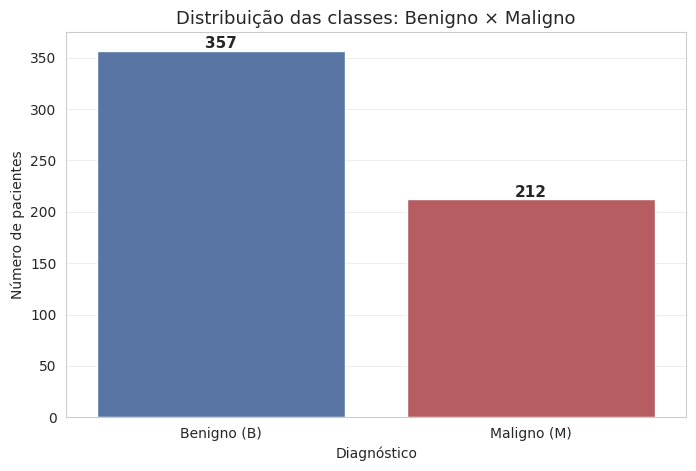

In [178]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x=TARGET_COL, data=df, order=[NEGATIVE_RAW, POSITIVE_RAW], hue=TARGET_COL, palette={NEGATIVE_RAW:'#4C72B0', POSITIVE_RAW: '#C44E52'})
ax.set_xticks([0, 1])
ax.set_xticklabels([f'{NEGATIVE_LABEL} (B)', f'{POSITIVE_LABEL} (M)'])
plt.title('Distribuição das classes: Benigno × Maligno', fontsize=13)
plt.xlabel('Diagnóstico')
plt.ylabel('Número de pacientes')

# Anotar valores absolutos sobre cada barra
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.show()

### 2.4 Distribuição das features (histogramas)

Plotar todas as 30 features simultaneamente em uma grade 6×5 oferece uma visão geral rápida de:

- **Forma da distribuição** (normal, assimétrica, multimodal).
- **Escala absoluta** (algumas em centésimos, outras em milhares, o que confirma necessidade de scaling).
- **Outliers** (caudas longas à direita, ex.: `area_mean`, `area_worst`). A implicação para a escolha do scaler é discutida na Etapa 3.4.

Outliers não foram removidos: em dados clínicos, valores extremos representam pacientes reais, não erros de medição. Um tumor com `area_worst` muito elevado é exatamente o caso que o modelo precisa aprender a classificar corretamente. Removê-los enviesaria o modelo contra as apresentações mais atípicas e potencialmente mais graves.


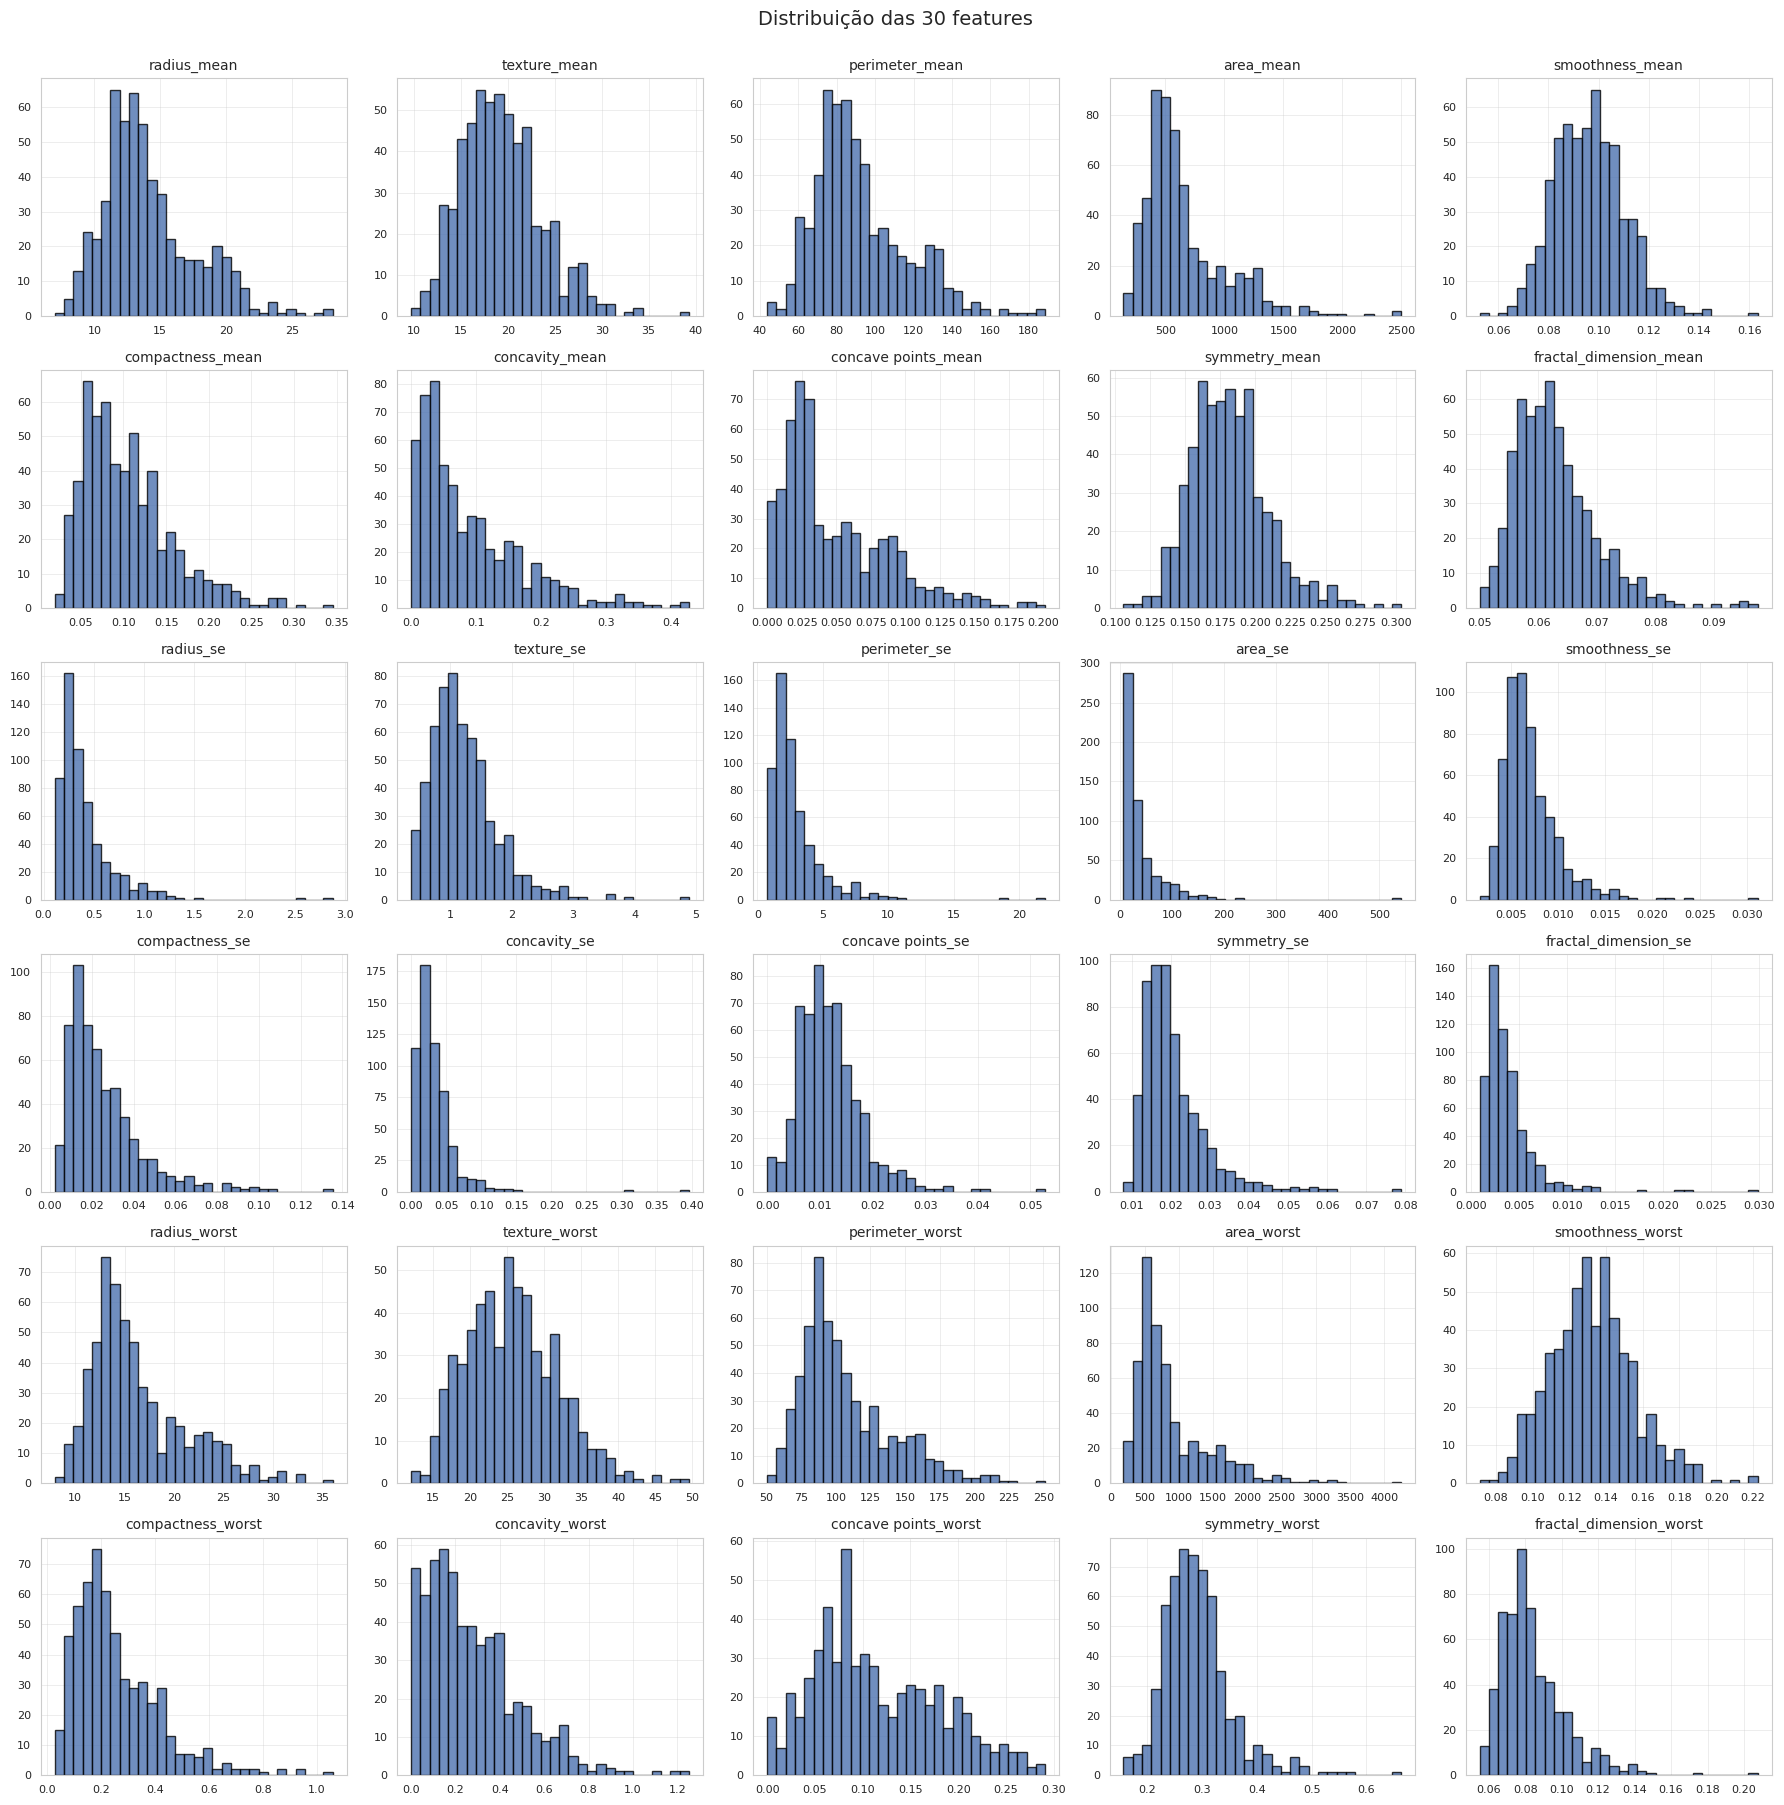

In [179]:
# Histograma de cada feature numérica (descartando id, target e Unnamed: 32)
features_numericas = df.drop(columns=COLS_TO_DROP + [TARGET_COL]).columns

fig, axes = plt.subplots(6, 5, figsize=(18, 18))
axes = axes.flatten()

for i, col in enumerate(features_numericas):
    axes[i].hist(df[col], bins=30, color='#4C72B0', edgecolor='black', alpha=0.8)
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(labelsize=8)

plt.suptitle('Distribuição das 30 features', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

### 2.5 Correlação entre features

O heatmap de correlação revela multicolinearidade: pares de features que carregam essencialmente a mesma informação. No Breast Cancer Wisconsin esse fenômeno é estrutural: como `area = π × radius²` e `perimeter = 2π × radius`, esses três grupos de features apresentarão correlação ≈ 1,0 dentro de cada bloco (`mean`, `se`, `worst`).

A multicolinearidade não impede modelos baseados em árvore (RF, DT), mas degrada estimativas de coeficientes em Regressão Logística e prejudica modelos baseados em distância (**KNN, SVM**), motivos para tratar isso na Etapa 2.7.2 (drop de features correlacionadas).

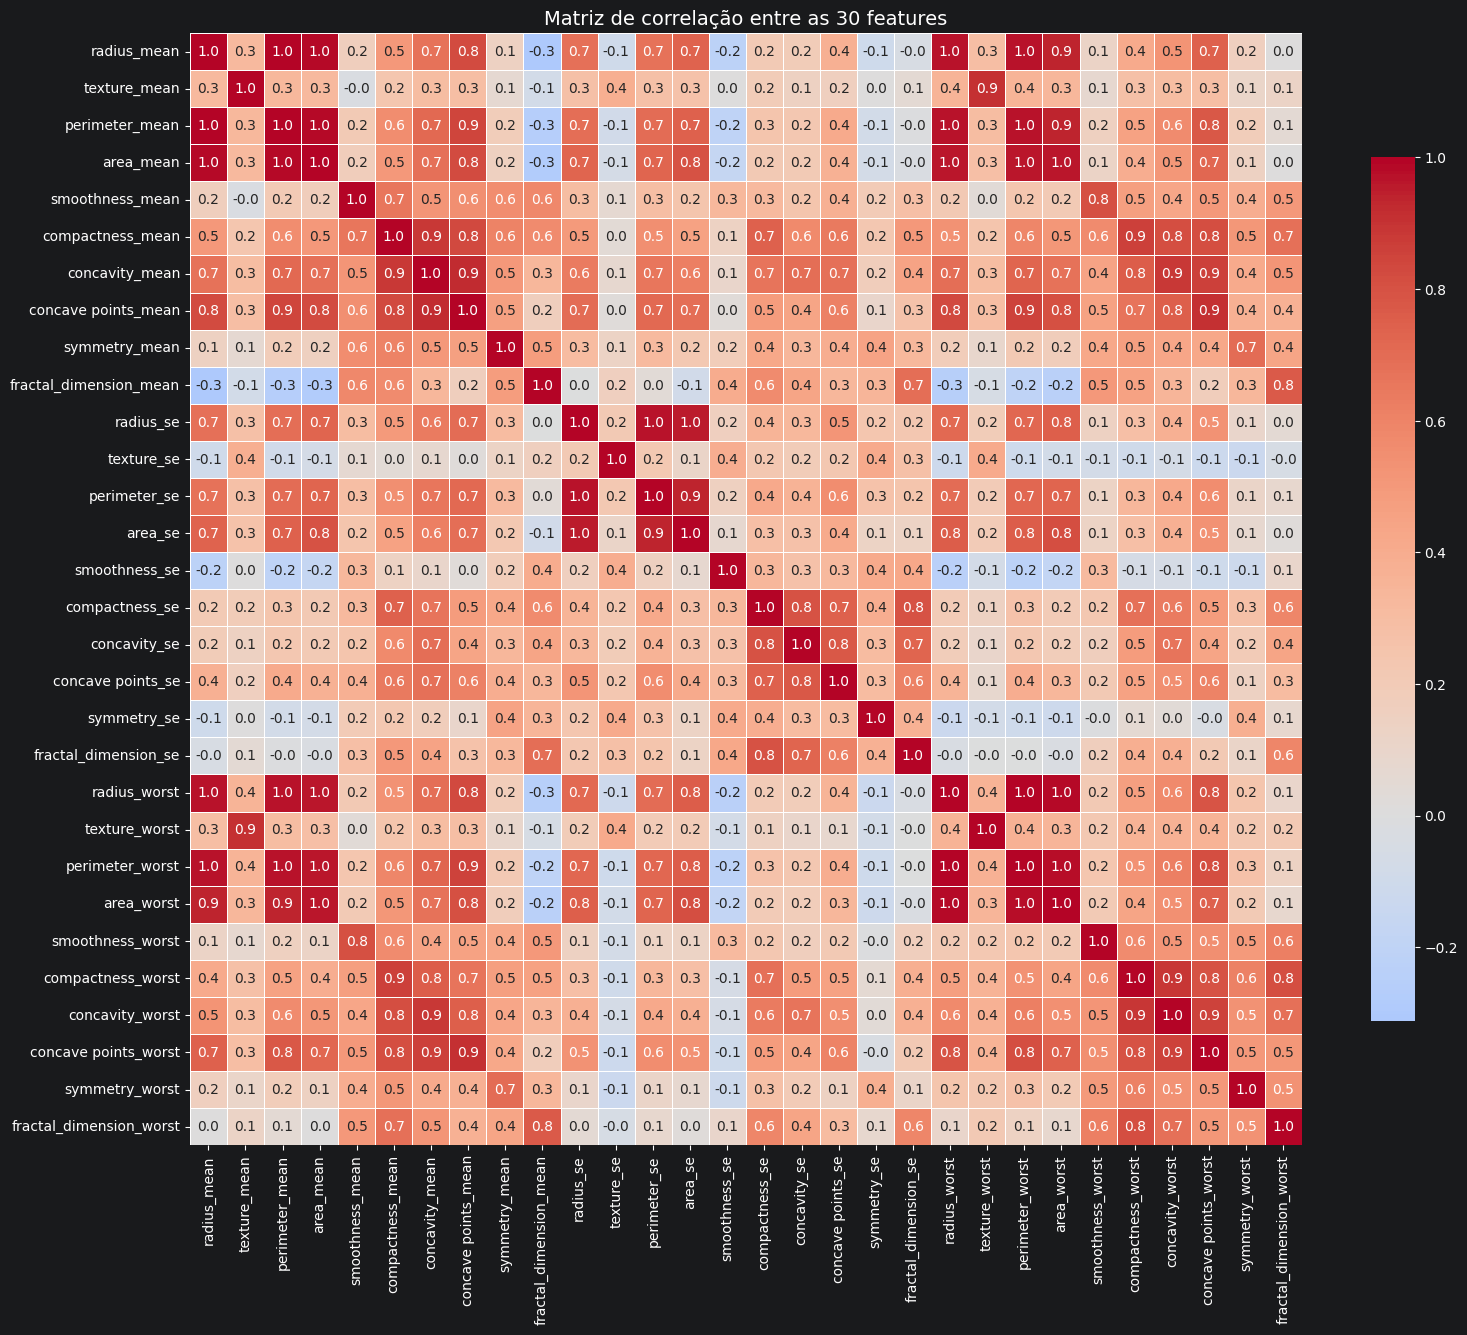

In [180]:
corr = df.drop(columns=COLS_TO_DROP + [TARGET_COL]).corr()

plt.figure(figsize=(16, 14))
sns.heatmap(corr, annot=True, fmt='.1f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.7})
plt.title('Matriz de correlação entre as 30 features', fontsize=14)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 2.6 Correlação das features com a target

Após codificar a target em valor numérico (`B` → 0, `M` → 1), calculamos a correlação de cada feature com o diagnóstico. Essa lista, ordenada decrescentemente, antecipa quais features serão mais discriminativas no modelo final.

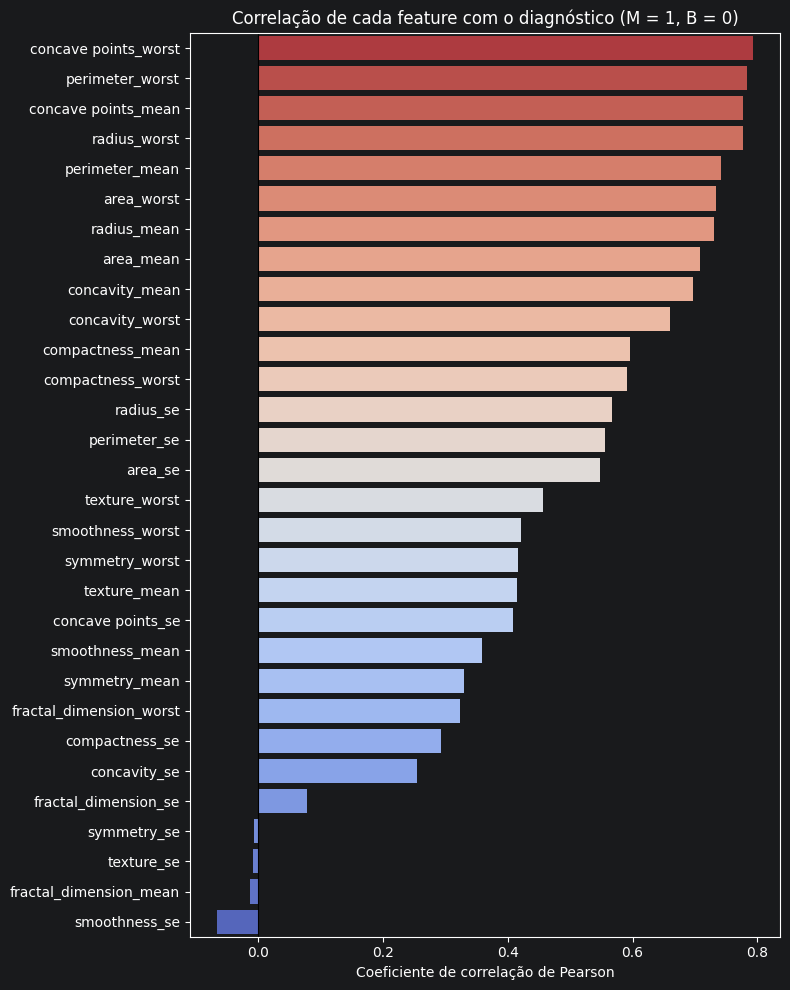

=== Top 10 features mais correlacionadas com malignidade ===
concave points_worst    0.794
perimeter_worst         0.783
concave points_mean     0.777
radius_worst            0.776
perimeter_mean          0.743
area_worst              0.734
radius_mean             0.730
area_mean               0.709
concavity_mean          0.696
concavity_worst         0.660
Name: diagnosis, dtype: float64


In [181]:
# Correlação de cada feature com a target (apenas para visualização: encoding oficial será na Etapa 3)
df_temp = df.drop(columns=COLS_TO_DROP).copy()
df_temp[TARGET_COL] = (df_temp[TARGET_COL] == POSITIVE_RAW).astype(int)

corr_target = df_temp.corr()[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False)

plt.figure(figsize=(8, 10))
sns.barplot(x=corr_target.values, y=corr_target.index,
            hue=corr_target.index, palette='coolwarm_r', legend=False)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlação de cada feature com o diagnóstico (M = 1, B = 0)', fontsize=12)
plt.xlabel('Coeficiente de correlação de Pearson')
plt.ylabel('')
plt.tight_layout()
plt.show()

print('=== Top 10 features mais correlacionadas com malignidade ===')
print(corr_target.head(10).round(3))

---

### 2.7 Visualização Avançada e Feature Selection

Antes das análises por classe, separamos features e target. Esta separação é somente para fins exploratórios: o pipeline oficial (com `train_test_split` + `StandardScaler` + estimador) será construído na Etapa 3.

In [182]:
X = df.drop(columns=COLS_TO_DROP + [TARGET_COL])
y = (df[TARGET_COL] == POSITIVE_RAW).astype(int)   # 1 = Maligno, 0 = Benigno

print(f'X.shape: {X.shape}')                       # (569, 30)
print(f'y.shape: {y.shape}')                       # (569,)
print(f'Distribuição de y: {dict(y.value_counts())}')

X.shape: (569, 30)
y.shape: (569,)
Distribuição de y: {0: np.int64(357), 1: np.int64(212)}


### 2.7.1 Distribuições por classe: boxplot + pontos individuais

**Estrutura do dataset BC**: as 30 features estão organizadas em **3 blocos de 10**:
- **`mean`** (índices 0-9): valor médio da característica do núcleo celular
- **`se`** (índices 10-19): erro padrão (variabilidade entre núcleos)
- **`worst`** (índices 20-29): pior valor observado (média dos 3 maiores)

Plotar os 3 grupos separadamente evita poluição visual e permite comparar as 3 versões da mesma característica. O boxplot mostra mediana e quartis; os pontos individuais (stripplot) exibem a distribuição real dos dados sem suavização. Features com pouca sobreposição entre maligno e benigno são as mais discriminativas para o modelo.


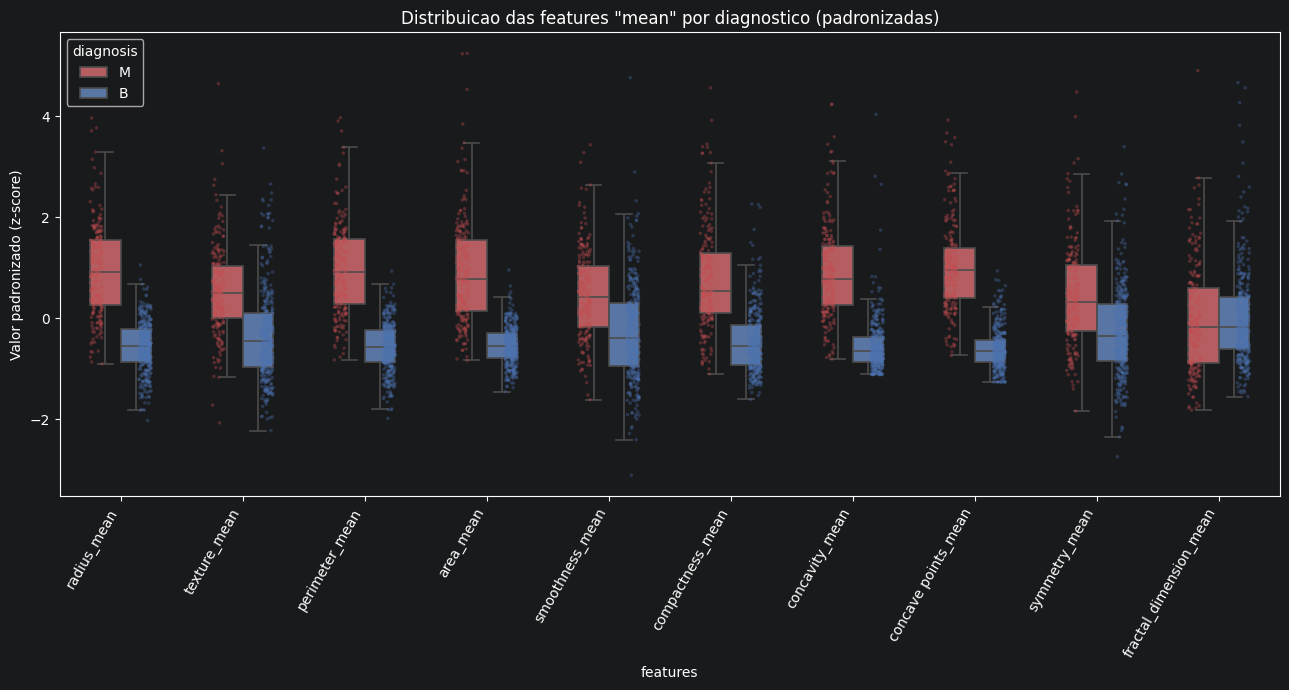

In [183]:
# Padronizar apenas para visualização (não interfere no pipeline da Etapa 3)
data_std = (X - X.mean()) / X.std()

# Recriar a coluna target nominal (M/B) para o hue
y_nominal = df[TARGET_COL]

PALETTE = {NEGATIVE_RAW: '#4C72B0', POSITIVE_RAW: '#C44E52'}

def plot_box_strip_group(start, end, group_name):
    data_viz = pd.concat([y_nominal, data_std.iloc[:, start:end]], axis=1)
    data_viz = pd.melt(data_viz, id_vars=TARGET_COL, var_name='features', value_name='value')

    fig, ax = plt.subplots(figsize=(13, 7))
    sns.boxplot(x='features', y='value', hue=TARGET_COL, data=data_viz,
                showfliers=False, width=0.5, palette=PALETTE, linewidth=1.2, ax=ax)
    sns.stripplot(x='features', y='value', hue=TARGET_COL, data=data_viz,
                  jitter=True, dodge=True, size=2.5, alpha=0.35, palette=PALETTE,
                  legend=False, ax=ax)
    plt.setp(ax.get_xticklabels(), rotation=60, ha='right')
    ax.set_title(f'Distribuicao das features "{group_name}" por diagnostico (padronizadas)', fontsize=12)
    ax.set_ylabel('Valor padronizado (z-score)')
    plt.tight_layout()
    plt.show()


# Bloco 1: features _mean (0-9)
plot_box_strip_group(0, 10, 'mean')


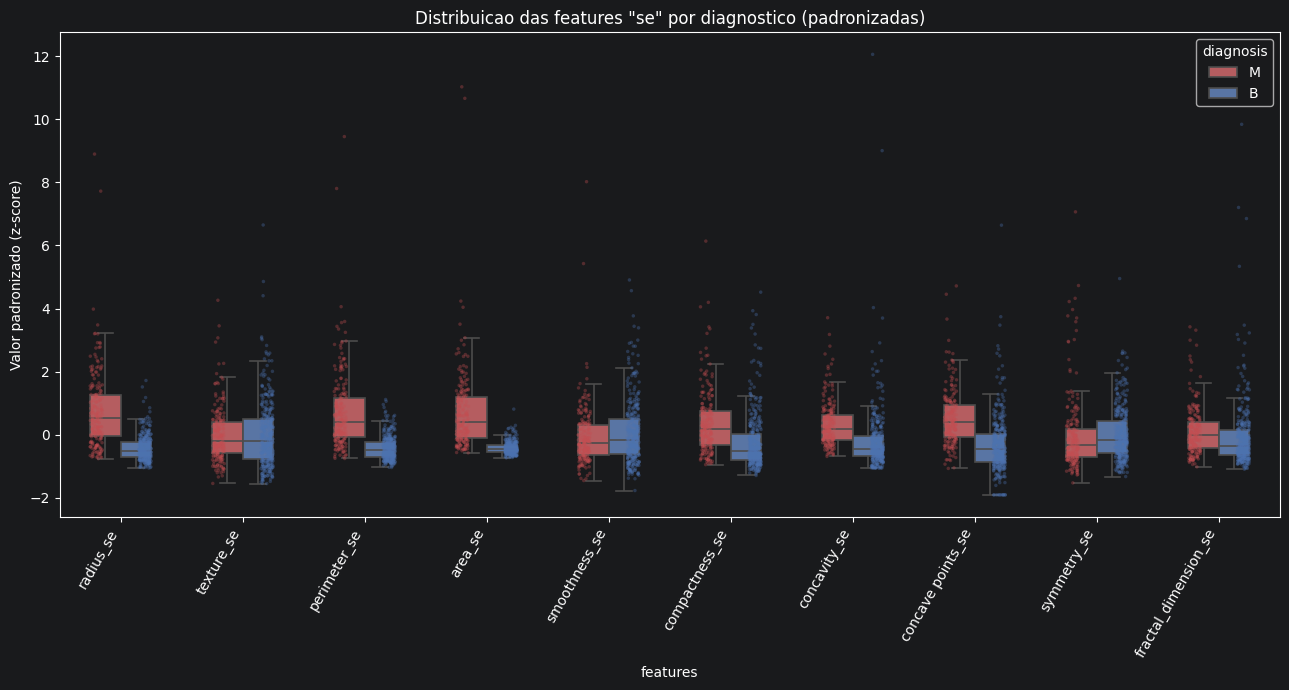

In [184]:
# Bloco 2: features _se (10-19): variabilidade
plot_box_strip_group(10, 20, 'se')


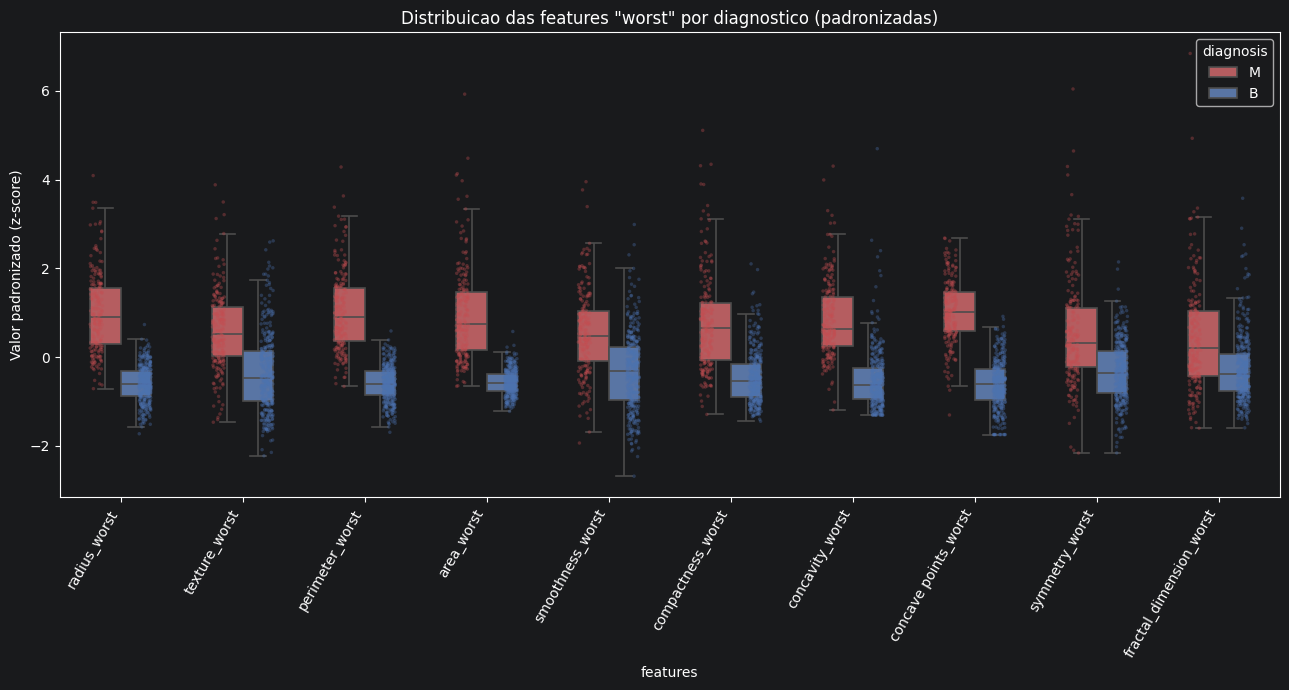

In [185]:
# Bloco 3: features _worst (20-29): pior valor por amostra
plot_box_strip_group(20, 30, 'worst')


### 2.7.2 Drop manual por correlação alta (multicolinearidade)

A partir do heatmap (Etapa 2.5), identificamos pares com `|corr| > 0,9`. Removemos uma feature de cada par, priorizando a de maior correlação com o target (Etapa 2.6) e menor redundância:

- **Família radius/perimeter/area**: as três são geometricamente dependentes. Mantemos `area_mean` e `area_se`; removemos `radius_*`, `perimeter_*` e `area_worst`.
- **Bloco `_se` redundante**: `compactness_se` e `concave points_se` removidos por alta correlação com seus pares `_mean`.
- **`_mean` × `_worst` de alta correlação**: `compactness_mean`, `concave points_mean`, `texture_worst`, `compactness_worst` e `concave points_worst` removidos por redundância com suas versões `_worst` ou `_mean` mantidas.

Multicolinearidade prejudica especialmente **Regressão Logística** (instabilidade dos coeficientes) e modelos baseados em distância (SVM). Random Forest é robusto a isso, mas reduzir features melhora interpretabilidade e velocidade de treino.

`X_reduced` é gerado aqui apenas para visualizar a redução de correlação no heatmap abaixo. As Etapas 2.7.3 e 2.7.4 usam `X` completo (análise exploratória independente), e a modelagem (Etapa 4) também usa `X` completo.


In [186]:
# Lista de features altamente correlacionadas a remover (baseada no heatmap da Etapa 2.5)
drop_list = [
    'perimeter_mean', 'radius_mean', 'compactness_mean', 'concave points_mean',
    'radius_se', 'perimeter_se', 'radius_worst', 'perimeter_worst',
    'compactness_worst', 'concave points_worst', 'compactness_se',
    'concave points_se', 'texture_worst', 'area_worst'
]

X_reduced = X.drop(columns=drop_list)

print(f'Features originais: {X.shape[1]}')
print(f'Features após drop: {X_reduced.shape[1]}')
print(f'Features removidas ({len(drop_list)}):')
for f in drop_list:
    print(f'  - {f}')

print(f'\nFeatures mantidas ({X_reduced.shape[1]}):')
for f in X_reduced.columns.tolist():
    print(f'  - {f}')

Features originais: 30
Features após drop: 16
Features removidas (14):
  - perimeter_mean
  - radius_mean
  - compactness_mean
  - concave points_mean
  - radius_se
  - perimeter_se
  - radius_worst
  - perimeter_worst
  - compactness_worst
  - concave points_worst
  - compactness_se
  - concave points_se
  - texture_worst
  - area_worst

Features mantidas (16):
  - texture_mean
  - area_mean
  - smoothness_mean
  - concavity_mean
  - symmetry_mean
  - fractal_dimension_mean
  - texture_se
  - area_se
  - smoothness_se
  - concavity_se
  - symmetry_se
  - fractal_dimension_se
  - smoothness_worst
  - concavity_worst
  - symmetry_worst
  - fractal_dimension_worst


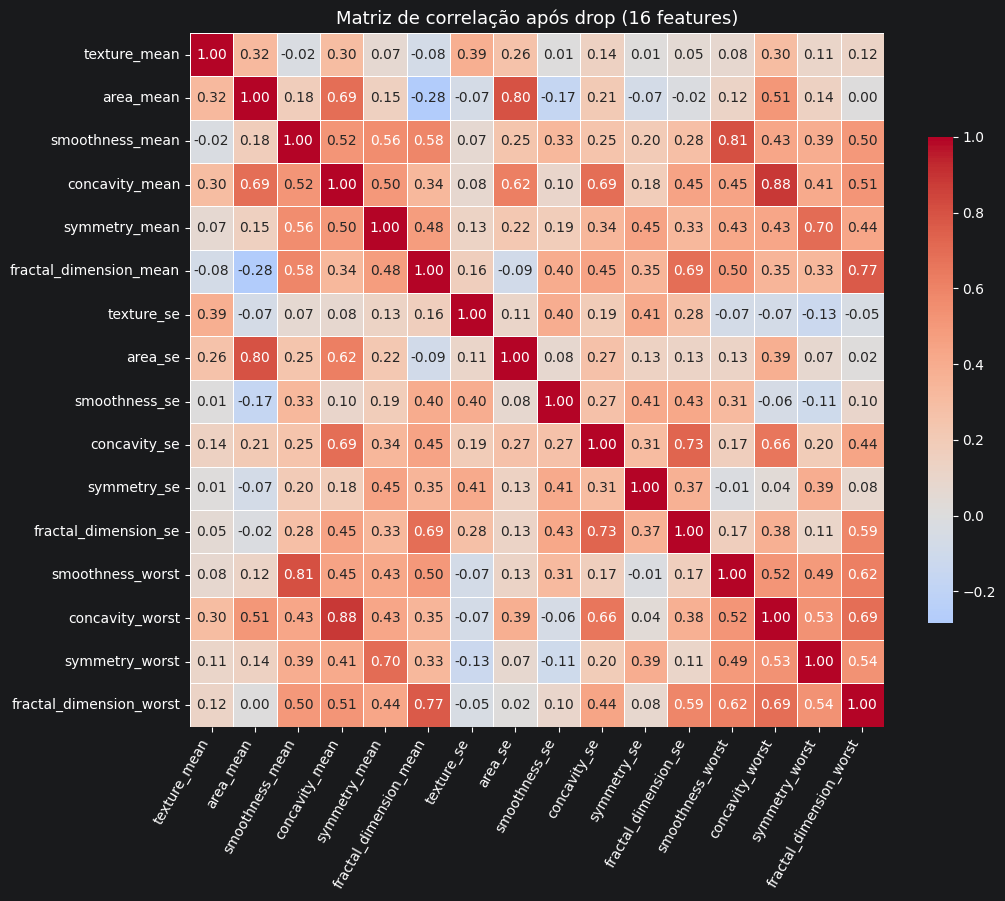

In [187]:
# Verificar visualmente que a multicolinearidade reduziu (heatmap após drop)
plt.figure(figsize=(11, 9))
sns.heatmap(X_reduced.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.7})
plt.title(f'Matriz de correlação após drop ({X_reduced.shape[1]} features)', fontsize=13)
plt.xticks(rotation=60, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 2.7.3 Feature selection automatizada

Aplicamos 2 técnicas para validar (ou refinar) a escolha manual:

- **`RFE` (Recursive Feature Elimination)**: treina um modelo, descarta a feature menos importante, repete. Considera interações entre features (multivariado). Aqui usamos `RandomForestClassifier` como avaliador.
- **`RFECV`**: variante do RFE que usa cross-validation para escolher automaticamente o número ótimo de features.

As técnicas são aplicadas aqui sobre `X` completo para fins exploratórios. Os resultados não alimentam o modelo final, que usa `X_train` completo dentro de um `Pipeline`.

In [188]:
from sklearn.feature_selection import RFE, RFECV
from sklearn.ensemble import RandomForestClassifier

# (a) RFE: top 5 features pelo Random Forest (multivariado)
rfe = RFE(estimator=RandomForestClassifier(random_state=42, n_estimators=100),
          n_features_to_select=5, step=1).fit(X, y)
top_rfe = X.columns[rfe.support_].tolist()
print('Top 5 features (RFE com RandomForest):')
for f in top_rfe:
    print(f'  - {f}')

Top 5 features (RFE com RandomForest):
  - concave points_mean
  - radius_worst
  - perimeter_worst
  - area_worst
  - concave points_worst


Número ótimo de features (RFECV, otimizado para recall): 18

Features escolhidas pelo RFECV:
  - radius_mean
  - texture_mean
  - perimeter_mean
  - area_mean
  - compactness_mean
  - concavity_mean
  - concave points_mean
  - radius_se
  - area_se
  - radius_worst
  - texture_worst
  - perimeter_worst
  - area_worst
  - smoothness_worst
  - compactness_worst
  - concavity_worst
  - concave points_worst
  - symmetry_worst


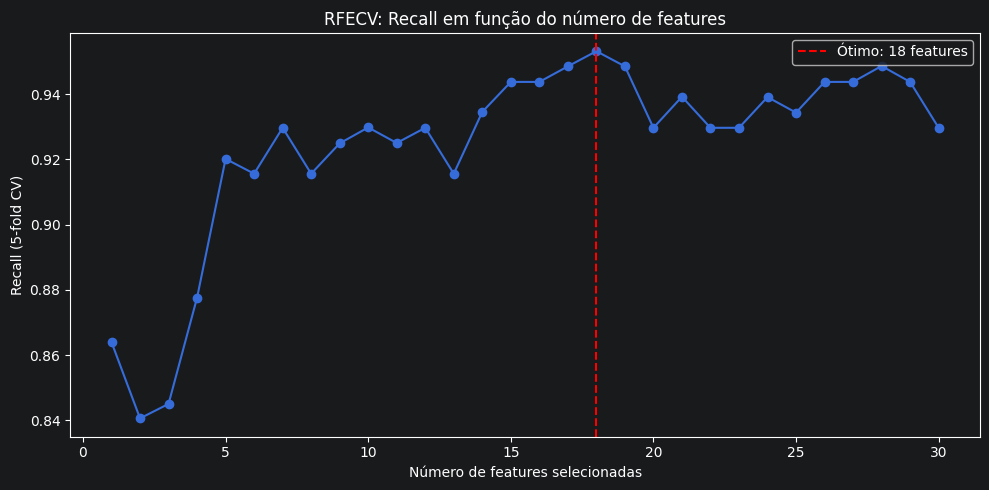

In [189]:
# (b) RFECV: escolhe automaticamente o nº ótimo de features otimizando recall
rfecv = RFECV(estimator=RandomForestClassifier(random_state=42, n_estimators=100),
              step=1, cv=5, scoring='recall').fit(X, y)

print(f'Número ótimo de features (RFECV, otimizado para recall): {rfecv.n_features_}')
print('\nFeatures escolhidas pelo RFECV:')
for f in X.columns[rfecv.support_].tolist():
    print(f'  - {f}')

# Plotar curva de recall × nº de features
plt.figure(figsize=(10, 5))
mean_scores = rfecv.cv_results_['mean_test_score']
plt.plot(range(1, len(mean_scores) + 1), mean_scores, marker='o')
plt.axvline(rfecv.n_features_, color='red', linestyle='--',
            label=f'Ótimo: {rfecv.n_features_} features')
plt.xlabel('Número de features selecionadas')
plt.ylabel('Recall (5-fold CV)')
plt.title('RFECV: Recall em função do número de features')
plt.legend()
plt.tight_layout()
plt.show()

**RFE vs. seleção manual (Etapa 2.7.2)**: as features selecionadas pelo RFE/RFECV nem sempre coincidem com as removidas pela análise de correlação, pois os métodos trabalham em perspectivas distintas.

- **Seleção manual**: correlação bivariada de Pearson. Remove redundâncias entre features (multicolinearidade) e features com baixa correlação individual com `diagnosis`.
- **RFE/RFECV**: avalia importância em contexto multivariado. Pode manter features de correlação individual moderada quando elas contribuem ao conjunto como um todo.

Ambas as análises são exploratórias. A modelagem (Etapa 4) usa `X` completo, permitindo que os algoritmos (especialmente o Random Forest) trabalhem com todas as features disponíveis. RFE e seleção por correlação serviram aqui para entender a estrutura dos dados antes de modelar.


### 2.7.4 PCA: Análise de Componentes Principais

PCA é uma técnica de **redução de dimensionalidade** que transforma as 30 features originais em componentes ortogonais (não-correlacionados) ordenados pela variância que explicam. Em datasets com muita multicolinearidade (caso do BC), poucos componentes capturam a maior parte da variância total.

Por que padronizar antes: PCA é sensível à escala. Uma feature com magnitude 1000× maior dominaria os componentes apenas pela escala bruta, não pela informação. Sempre aplicar `StandardScaler` antes do PCA.

Trade-off em contexto médico: ganha-se compactação, perde-se interpretabilidade (componentes não são mais features clinicamente reconhecíveis como 'raio do núcleo'). Neste projeto, a modelagem usa `X` completo com todas as features originais, sem redução dimensional.

O PCA abaixo é aplicado sobre `X_scaled` (dataset completo padronizado) apenas para fins exploratórios. Em produção, deve ser encapsulado dentro de um `Pipeline` e ajustado somente sobre `X_train`. Aplicar PCA antes do split ou fora do Pipeline constitui data leakage.

Três análises sequenciais:
- **(a) Variância acumulada**: quantos componentes preservam 95% da informação?
- **(b) Screeplot**: variância individual de cada componente.
- **(c) Biplot 2D**: verificar se as 2 primeiras componentes preservam a separação maligno × benigno.


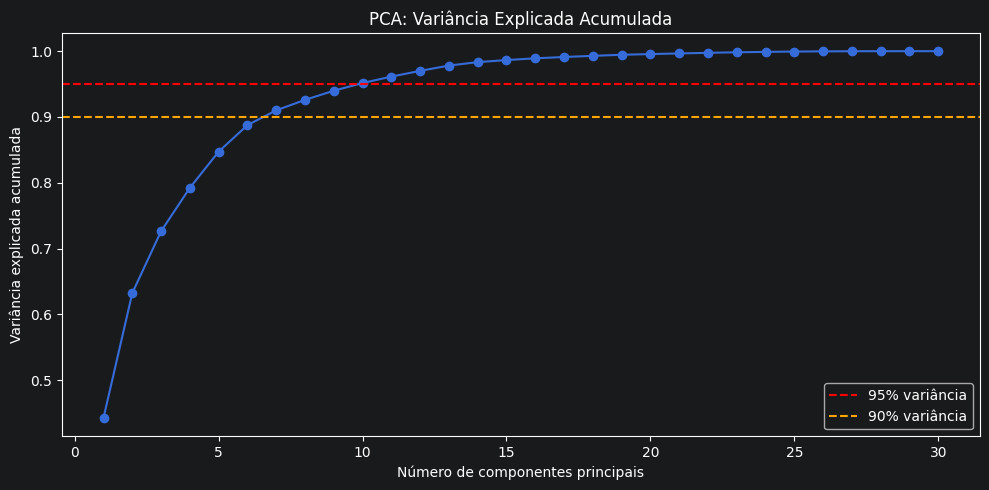

Componentes para preservar 90% da variância: 7
Componentes para preservar 95% da variância: 10


In [190]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Padronização exploratória (a Etapa 3 fará isso oficialmente dentro do pipeline)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Ajustar PCA com TODOS os componentes (= nº de features)
pca_full = PCA().fit(X_scaled)

# (a) Variância explicada acumulada
plt.figure(figsize=(10, 5))
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
plt.plot(range(1, len(cumvar) + 1), cumvar, marker='o')
plt.axhline(0.95, color='red', linestyle='--', label='95% variância')
plt.axhline(0.90, color='orange', linestyle='--', label='90% variância')
plt.xlabel('Número de componentes principais')
plt.ylabel('Variância explicada acumulada')
plt.title('PCA: Variância Explicada Acumulada')
plt.legend()
plt.tight_layout()
plt.show()

# Imprimir nº de componentes para 90% e 95%
n_90 = np.argmax(cumvar >= 0.90) + 1
n_95 = np.argmax(cumvar >= 0.95) + 1
print(f'Componentes para preservar 90% da variância: {n_90}')
print(f'Componentes para preservar 95% da variância: {n_95}')

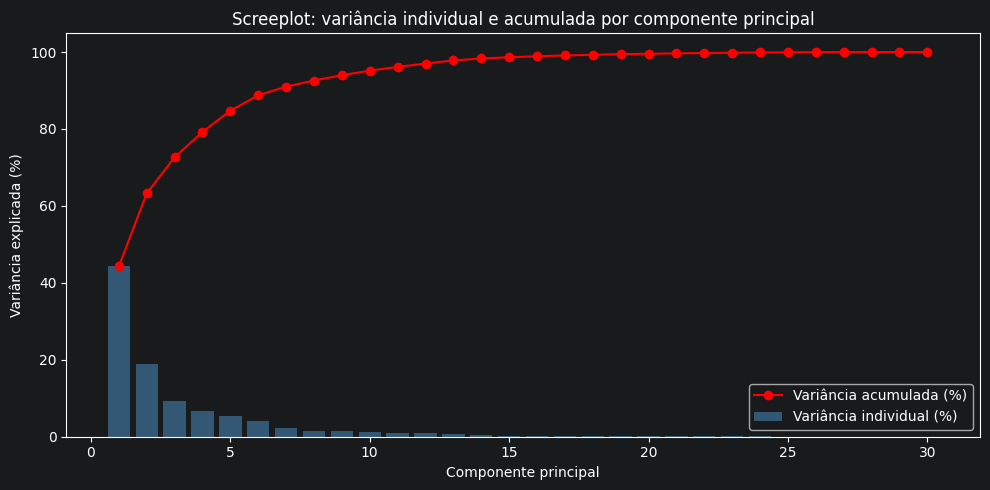

In [191]:
# (b) Screeplot: variância individual e acumulada por componente
plt.figure(figsize=(10, 5))
n = len(pca_full.explained_variance_ratio_)
plt.bar(range(1, n + 1), pca_full.explained_variance_ratio_ * 100,
        alpha=0.6, label='Variância individual (%)', color='steelblue')
plt.plot(range(1, n + 1), pca_full.explained_variance_ratio_.cumsum() * 100,
         marker='o', color='red', label='Variância acumulada (%)')
plt.xlabel('Componente principal')
plt.ylabel('Variância explicada (%)')
plt.title('Screeplot: variância individual e acumulada por componente principal')
plt.legend()
plt.tight_layout()
plt.show()

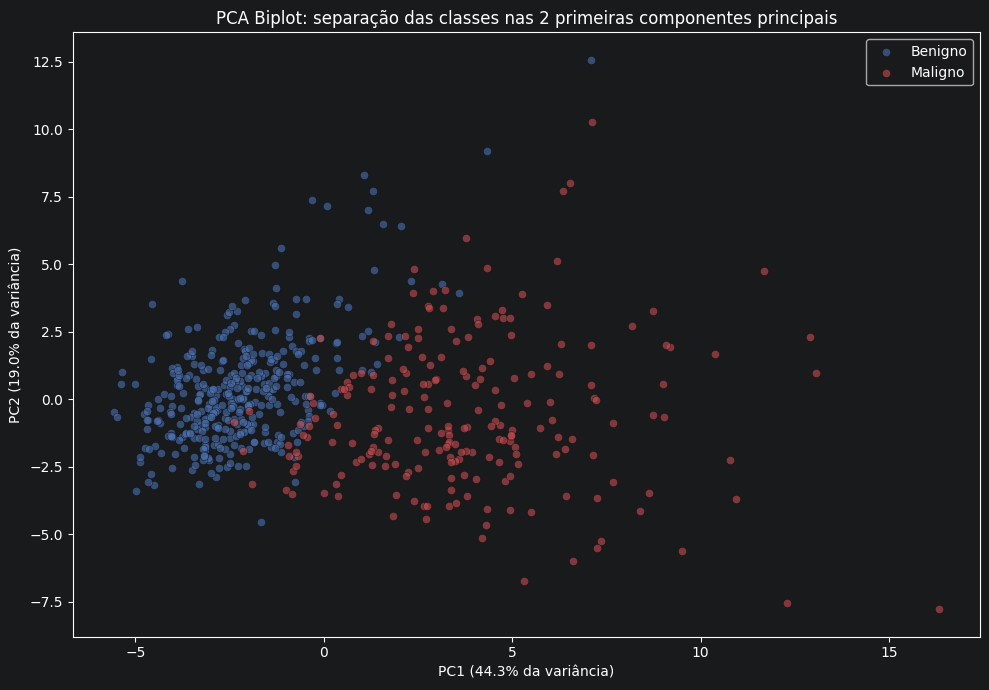

PC1 + PC2 explicam 63.2% da variância total


In [192]:
# (c) PCA Biplot 2D: verifica se as 2 primeiras componentes separam as classes
pca_2d = PCA(n_components=2).fit(X_scaled)
X_pca = pca_2d.transform(X_scaled)

plt.figure(figsize=(10, 7))
for label, color, name in [(0, '#4C72B0', NEGATIVE_LABEL), (1, '#C44E52', POSITIVE_LABEL)]:
    mask = y.values == label
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=color, label=name, alpha=0.6, edgecolors='k', linewidths=0.4)

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% da variância)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% da variância)')
plt.title('PCA Biplot: separação das classes nas 2 primeiras componentes principais')
plt.legend()
plt.tight_layout()
plt.show()

variancia_2pc = (pca_2d.explained_variance_ratio_.sum() * 100)
print(f'PC1 + PC2 explicam {variancia_2pc:.1f}% da variância total')

---

### 2.8 Análise de Outliers

Valores extremos em dados clínicos não são necessariamente erros de medição: podem representar casos biologicamente severos. Esta seção quantifica a presença de outliers com dois métodos complementares e avalia sua distribuição por classe antes de qualquer decisão sobre tratamento.

In [193]:
from scipy.stats import zscore

# Colunas numéricas preditivas (excluindo target e colunas não-preditivas)
numeric_cols = [c for c in df.select_dtypes(include='number').columns if c not in COLS_TO_DROP]

# --- IQR ---
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

outlier_mask_iqr = (df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))
n_outliers_iqr = outlier_mask_iqr.sum().sort_values(ascending=False)

print('Top 10 features com mais outliers (IQR):')
print(n_outliers_iqr.head(10).to_string())

Top 10 features com mais outliers (IQR):
area_se                    65
radius_se                  38
perimeter_se               38
area_worst                 35
smoothness_se              30
fractal_dimension_se       28
compactness_se             28
symmetry_se                27
area_mean                  25
fractal_dimension_worst    24


In [194]:
# --- Z-score ---
z_scores = df[numeric_cols].apply(zscore)
outlier_mask_zscore = z_scores.abs() > 3
n_outliers_zscore = outlier_mask_zscore.sum().sort_values(ascending=False)

# Comparação entre métodos
comparison = pd.DataFrame({
    'IQR': n_outliers_iqr,
    'Z-score (>3)': n_outliers_zscore
}).sort_values('IQR', ascending=False)

print('Comparação IQR x Z-score - top 10 features:')
print(comparison.head(10).to_string())

Comparação IQR x Z-score - top 10 features:
                         IQR  Z-score (>3)
area_se                   65             6
perimeter_se              38             8
radius_se                 38             7
area_worst                35            10
smoothness_se             30             7
compactness_se            28            12
fractal_dimension_se      28            10
symmetry_se               27            11
area_mean                 25             8
fractal_dimension_worst   24             9


Proporção de amostras com pelo menos um outlier por classe:
         IQR (%)  Z-score (%)
Benigno     16.0          7.0
Maligno     53.8         23.1


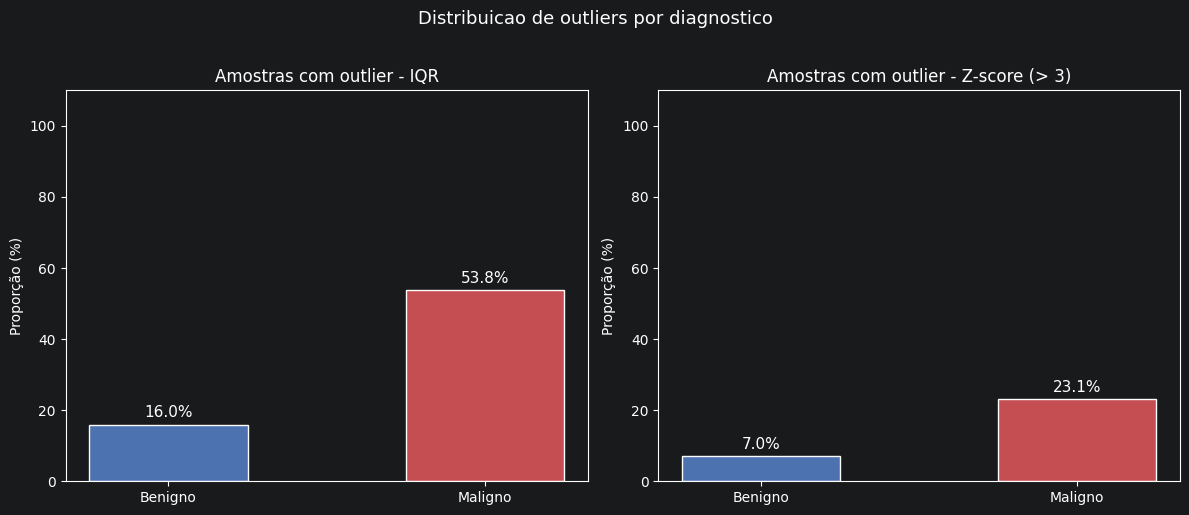

In [195]:
# --- Proporção de outliers por classe ---
df_out = df[[TARGET_COL]].copy()
df_out['has_outlier_iqr']    = outlier_mask_iqr.any(axis=1).values
df_out['has_outlier_zscore'] = outlier_mask_zscore.any(axis=1).values

outlier_by_class = (
    df_out.groupby(TARGET_COL)[['has_outlier_iqr', 'has_outlier_zscore']]
    .mean()
    .rename(columns={'has_outlier_iqr': 'IQR (%)', 'has_outlier_zscore': 'Z-score (%)'})
    * 100
).round(1)
outlier_by_class.index = [POSITIVE_LABEL if x == POSITIVE_RAW else NEGATIVE_LABEL for x in outlier_by_class.index]
print('Proporção de amostras com pelo menos um outlier por classe:')
print(outlier_by_class.to_string())

# --- Visualização ---
palette = {NEGATIVE_RAW: '#4C72B0', POSITIVE_RAW: '#C44E52'}
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, title in zip(
    axes,
    ['has_outlier_iqr', 'has_outlier_zscore'],
    ['IQR', 'Z-score (> 3)']
):
    prop = df_out.groupby(TARGET_COL)[col].mean() * 100
    labels = [NEGATIVE_LABEL if c == NEGATIVE_RAW else POSITIVE_LABEL for c in prop.index]
    colors = [palette[c] for c in prop.index]
    bars = ax.bar(labels, prop.values, color=colors, edgecolor='white', width=0.5)
    ax.set_title(f'Amostras com outlier - {title}', fontsize=12)
    ax.set_ylabel('Proporção (%)')
    ax.set_ylim(0, 110)
    for bar, val in zip(bars, prop.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 2, f'{val:.1f}%', ha='center', fontsize=11)

plt.suptitle('Distribuicao de outliers por diagnostico', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

A classe maligna concentra proporcionalmente mais amostras com outliers do que a benigna, em ambos os métodos. Isso é esperado sob o ponto de vista clínico: tumores malignos tendem a apresentar núcleos celulares com morfologia extrema (raio, área e concavidade muito elevados), o que se traduz em valores fora do intervalo típico da população.

Os outliers não serão removidos. A análise por classe evidencia que eles representam, em sua maioria, casos clínicos reais da classe maligna. Removê-los reduziria artificialmente a diversidade de padrões da classe de interesse clínico, comprometendo a capacidade do modelo de identificar casos severos. O `StandardScaler` (z-score) aplicado na Etapa 3 padroniza as escalas sem eliminar esses pontos extremos.

## Etapa 3: Pré-processamento de Dados
### 3.1 Remoção de colunas não-preditivas

As colunas `id` e `Unnamed: 32`, identificadas na inspeção inicial (Etapa 0.3) como não-preditivas, são removidas definitivamente aqui. O código confirma os valores antes do drop.


In [196]:
# Inspecionar antes de remover (documentação da decisão)
print('=== Colunas a remover ===')
for col in COLS_TO_DROP:
    if col in df.columns:
        nuniq = df[col].nunique()
        nnull = df[col].isnull().sum()
        print(f'{col:20s}: {nuniq:4d} valores únicos, {nnull:4d} nulos de {df.shape[0]} linhas')

df = df.drop(columns=COLS_TO_DROP, errors='ignore')
print(f'\nShape após limpeza: {df.shape}')   # esperado: (569, 31)

=== Colunas a remover ===
id                  :  569 valores únicos,    0 nulos de 569 linhas
Unnamed: 32         :    0 valores únicos,  569 nulos de 569 linhas

Shape após limpeza: (569, 31)


In [197]:
# Confirmar ausência de nulos restantes
print('Nulos por coluna após limpeza:')
print(df.isnull().sum()[df.isnull().sum() > 0].to_string() or 'Nenhum nulo restante.')

Nulos por coluna após limpeza:
Series([], )


### 3.2 Encoding da variável target

Usamos `LabelEncoder` do sklearn para converter `diagnosis` de string para inteiro. `LabelEncoder` codifica em ordem alfabética: `B→0` e `M→1`, que coincide com a convenção correta para este dataset (Benigno = 0, Maligno = 1).


In [198]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df[TARGET_COL] = le.fit_transform(df[TARGET_COL])

print(f'Classes aprendidas pelo LabelEncoder: {le.classes_}')  # ['B' 'M'] → B=0, M=1
print(f'\nDistribuição após encoding:')
print(df[TARGET_COL].value_counts())
print(f'\nTipo da coluna: {df[TARGET_COL].dtype}')   # deve ser int64

Classes aprendidas pelo LabelEncoder: ['B' 'M']

Distribuição após encoding:
diagnosis
0    357
1    212
Name: count, dtype: int64

Tipo da coluna: int64


### 3.3 Separação treino / teste: split estratificado

`train_test_split` com `stratify=y` garante que a proporção 62,74% benignos × 37,26% malignos seja preservada em ambos os conjuntos. Sem `stratify`, uma divisão azarada poderia concentrar malignos em um dos lados, enviesando treino e avaliação.

- `test_size=0.2`: 80% treino (455 amostras) / 20% teste (114 amostras)
- `random_state=42`: reprodutibilidade

In [199]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'X_train: {X_train.shape}  |  y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}   |  y_test:  {y_test.shape}')
print(f'\nProporção maligno no treino: {y_train.mean()*100:.2f}%')
print(f'Proporção maligno no teste:  {y_test.mean()*100:.2f}%')

X_train: (455, 30)  |  y_train: (455,)
X_test:  (114, 30)   |  y_test:  (114,)

Proporção maligno no treino: 37.36%
Proporção maligno no teste:  36.84%


### 3.4 StandardScaler: justificativa de uso

Features como `area_mean` (média ≈ 654, máx ≈ 2501) e `smoothness_mean` (média ≈ 0,096) estão em escalas radicalmente diferentes. **Modelos afetados**:

- **Regressão Logística**: usa regularização (penalidade L2/L1) baseada na magnitude dos coeficientes. Sem scaling, features de maior escala recebem coeficientes artificialmente menores, distorcendo a penalização.
- **SVM**: o kernel `rbf` computa distâncias no espaço de features. Sem scaling, features de grande magnitude dominam o cálculo, tornando o hiperplano enviesado.
- **Random Forest / Decision Tree**: **não exigem scaling**. Baseados em limiares (`if feature > X`), invariantes à escala. O scaling não prejudica, mas tampouco ajuda.

Optamos por `StandardScaler` (z-score: subtrai a média, divide pelo desvio-padrão) em vez de `MinMaxScaler` porque distribuições com caudas longas comprimiriam a maioria dos dados num intervalo estreito com o MinMaxScaler.

`StandardScaler` é sensível a outliers: média e desvio-padrão são influenciados por valores extremos. Para este dataset, a intensidade dos outliers é moderada e a escolha é adequada. `RobustScaler` (mediana + IQR) é a alternativa para casos com outliers severos.

O scaler é ajustado apenas no `X_train` (`fit_transform`) e aplicado com `transform` no `X_test`, para evitar data leakage


### 3.5 Verificação do pré-processamento

Confirmar que o shape dos dados está correto e que o split respeitou o balanceamento antes de passar para a modelagem.


In [200]:
print('=== Resumo do pré-processamento ===')
print(f'Dataset final:  {df.shape[0]} amostras × {df.shape[1]-1} features')
print(f'Treino:         {X_train.shape[0]} amostras ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Teste:          {X_test.shape[0]} amostras ({X_test.shape[0]/len(X)*100:.1f}%)')
print(f'\nBalanceamento da target:')
print(f'  Treino : Benigno: {(y_train==0).sum()} ({(y_train==0).mean()*100:.1f}%) | Maligno: {(y_train==1).sum()} ({(y_train==1).mean()*100:.1f}%)')
print(f'  Teste  : Benigno: {(y_test==0).sum()}  ({(y_test==0).mean()*100:.1f}%)  | Maligno: {(y_test==1).sum()}  ({(y_test==1).mean()*100:.1f}%)')
print(f'\nFeatures: {list(X.columns)}')

=== Resumo do pré-processamento ===
Dataset final:  569 amostras × 30 features
Treino:         455 amostras (80.0%)
Teste:          114 amostras (20.0%)

Balanceamento da target:
  Treino : Benigno: 285 (62.6%) | Maligno: 170 (37.4%)
  Teste  : Benigno: 72  (63.2%)  | Maligno: 42  (36.8%)

Features: ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


---

## Etapa 4: Modelagem, Validação Cruzada e Tuning de Hiperparâmetros

### 4.0 Modelos escolhidos e justificativas

Os quatro modelos cobrem diferentes hipóteses sobre a estrutura dos dados:

- **Regressão Logística**: modelo linear interpretável; os coeficientes indicam a contribuição de cada feature. Baseline sólido. Exige scaling. Pode ter dificuldade com relações não-lineares.
- **SVM (Support Vector Machine)**: encontra o hiperplano de margem máxima entre as classes. Excelente em datasets pequenos/médios (~569 amostras). Exige scaling. O GridSearchCV (Etapa 4.3) testa automaticamente os kernels `linear` e `rbf`.
- **Árvore de Decisão**: regras IF/ELSE auditáveis. Alta interpretabilidade médica/regulatória. Não exige scaling. Tendência a overfitting sem regularização de profundidade.
- **Random Forest**: ensemble de árvores com bagging. Geralmente mais preciso que árvore única, robusto a overfitting. Feature importances nativas. Não exige scaling; o Pipeline aplica sem efeito matemático, mantendo uniformidade.

In [201]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
from sklearn.metrics import make_scorer, recall_score

# Scorer customizado: otimizar recall da classe positiva (maligno = 1)
recall_scorer = make_scorer(recall_score, pos_label=1)

# StratifiedKFold: 5 folds com embaralhamento: mantém proporção maligno/benigno em cada fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Configuração de validação cruzada:')
print(f'  Estratégia: StratifiedKFold')
print(f'  Folds: 5')
print(f'  Métrica de otimização: Recall (classe positiva = Maligno)')

Configuração de validação cruzada:
  Estratégia: StratifiedKFold
  Folds: 5
  Métrica de otimização: Recall (classe positiva = Maligno)


### 4.1 Pipelines base (sem tuning)

Cada modelo é encapsulado num `Pipeline(StandardScaler → Estimador)`, mantendo o scaling ajustado apenas nos dados de treino de cada fold e o código unificado para treino, predição e busca de hiperparâmetros.

Para Árvore e Random Forest, o scaling não tem efeito matemático (modelos invariantes à escala), mas mantemos o padrão para uniformidade do código.

In [202]:
pipelines_base = {
    'Regressão Logística': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  LogisticRegression(random_state=42, max_iter=10000))
    ]),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  SVC(random_state=42, probability=True))
    ]),
    'Árvore de Decisão': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  DecisionTreeClassifier(random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  RandomForestClassifier(random_state=42, n_jobs=-1))
    ]),
}

print('Pipelines criados:', list(pipelines_base.keys()))

Pipelines criados: ['Regressão Logística', 'SVM', 'Árvore de Decisão', 'Random Forest']


### 4.2 Validação cruzada: comparação baseline

`cross_validate` com múltiplas métricas simultâneas. Avaliamos:
- **Recall**: métrica primária (minimiza falsos negativos).
- **F1-score**: equilíbrio entre precision e recall.
- **Accuracy**: métrica secundária (referência geral).

Reportamos média ± desvio padrão sobre os 5 folds; o desvio padrão indica estabilidade do modelo: desvio alto = comportamento inconsistente entre folds.

In [203]:
import pandas as pd

scoring = {
    'recall':   recall_scorer,
    'f1':       'f1',
    'accuracy': 'accuracy',
}

resultados_base = {}

print('=== Cross-Validation Baseline (5 folds) ===\n')
for nome, pipeline in pipelines_base.items():
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    resultados_base[nome] = {
        'Recall (média)':    scores['test_recall'].mean(),
        'Recall (std)':      scores['test_recall'].std(),
        'F1 (média)':        scores['test_f1'].mean(),
        'F1 (std)':          scores['test_f1'].std(),
        'Accuracy (média)':  scores['test_accuracy'].mean(),
        'Accuracy (std)':    scores['test_accuracy'].std(),
    }
    print(f'{nome}:')
    print(f"  Recall:   {scores['test_recall'].mean():.4f} ± {scores['test_recall'].std():.4f}")
    print(f"  F1:       {scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}")
    print(f"  Accuracy: {scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}\n")

=== Cross-Validation Baseline (5 folds) ===

Regressão Logística:
  Recall:   0.9529 ± 0.0399
  F1:       0.9640 ± 0.0207
  Accuracy: 0.9736 ± 0.0149

SVM:
  Recall:   0.9471 ± 0.0343
  F1:       0.9610 ± 0.0082
  Accuracy: 0.9714 ± 0.0054

Árvore de Decisão:
  Recall:   0.8941 ± 0.0606
  F1:       0.8962 ± 0.0447
  Accuracy: 0.9231 ± 0.0326

Random Forest:
  Recall:   0.9412 ± 0.0416
  F1:       0.9519 ± 0.0207
  Accuracy: 0.9648 ± 0.0146



In [204]:
df_base = pd.DataFrame(resultados_base).T.round(4)
df_base = df_base.sort_values('Recall (média)', ascending=False)

print('=== Tabela Comparativa: Baseline (sem tuning) ===')
print(df_base.to_string())

=== Tabela Comparativa: Baseline (sem tuning) ===
                     Recall (média)  Recall (std)  F1 (média)  F1 (std)  Accuracy (média)  Accuracy (std)
Regressão Logística          0.9529        0.0399      0.9640    0.0207            0.9736          0.0149
SVM                          0.9471        0.0343      0.9610    0.0082            0.9714          0.0054
Random Forest                0.9412        0.0416      0.9519    0.0207            0.9648          0.0146
Árvore de Decisão            0.8941        0.0606      0.8962    0.0447            0.9231          0.0326


### 4.3 Tuning de Hiperparâmetros: GridSearchCV

`GridSearchCV` busca exaustivamente a combinação de hiperparâmetros que maximiza o recall médio na validação cruzada (5 folds StratifiedKFold). O conjunto de teste não é usado nessa etapa, ficando reservado para a avaliação final (Etapa 5).

**Prefixo `model__`** nos parâmetros: como o modelo está encapsulado no Pipeline, o GridSearchCV precisa do prefixo `<nome_do_passo>__<parâmetro>` para alcançar os parâmetros internos.

In [205]:
from sklearn.model_selection import GridSearchCV

# === Logistic Regression ===
param_grid_lr = {
    'model__C':       [0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2'],
    'model__solver':  ['liblinear'],        # suporta l1 e l2
}

grid_lr = GridSearchCV(
    estimator=pipelines_base['Regressão Logística'],
    param_grid=param_grid_lr,
    scoring=recall_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=0,
    refit=True
)
grid_lr.fit(X_train, y_train)

print('=== Regressão Logística: Tuning ===')
print(f'Melhores parâmetros: {grid_lr.best_params_}')
print(f'Melhor Recall (CV):  {grid_lr.best_score_:.4f}')

=== Regressão Logística: Tuning ===
Melhores parâmetros: {'model__C': 0.01, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Melhor Recall (CV):  0.9588


In [206]:
# === SVM ===
param_grid_svm = {
    'model__C':      [0.1, 1, 10, 100],
    'model__kernel': ['linear', 'rbf'],
    'model__gamma':  ['scale', 'auto'],
}

grid_svm = GridSearchCV(
    estimator=pipelines_base['SVM'],
    param_grid=param_grid_svm,
    scoring=recall_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=0,
    refit=True
)
grid_svm.fit(X_train, y_train)

print('=== SVM: Tuning ===')
print(f'Melhores parâmetros: {grid_svm.best_params_}')
print(f'Melhor Recall (CV):  {grid_svm.best_score_:.4f}')

=== SVM: Tuning ===
Melhores parâmetros: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Melhor Recall (CV):  0.9647


In [207]:
# === Árvore de Decisão ===
param_grid_dt = {
    'model__max_depth':        [3, 5, 7, 10, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf':  [1, 2, 4],
    'model__criterion':         ['gini', 'entropy'],
}

grid_dt = GridSearchCV(
    estimator=pipelines_base['Árvore de Decisão'],
    param_grid=param_grid_dt,
    scoring=recall_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=0,
    refit=True
)
grid_dt.fit(X_train, y_train)

print('=== Árvore de Decisão: Tuning ===')
print(f'Melhores parâmetros: {grid_dt.best_params_}')
print(f'Melhor Recall (CV):  {grid_dt.best_score_:.4f}')

=== Árvore de Decisão: Tuning ===
Melhores parâmetros: {'model__criterion': 'gini', 'model__max_depth': 7, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5}
Melhor Recall (CV):  0.9000


In [208]:
# === Random Forest ===
param_grid_rf = {
    'model__n_estimators':      [100, 200, 300],
    'model__max_depth':         [5, 10, 20, None],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf':  [1, 2],
    'model__class_weight':      [None, 'balanced'],
}

grid_rf = GridSearchCV(
    estimator=pipelines_base['Random Forest'],
    param_grid=param_grid_rf,
    scoring=recall_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=0,
    refit=True
)
grid_rf.fit(X_train, y_train)

print('=== Random Forest: Tuning ===')
print(f'Melhores parâmetros: {grid_rf.best_params_}')
print(f'Melhor Recall (CV):  {grid_rf.best_score_:.4f}')

=== Random Forest: Tuning ===
Melhores parâmetros: {'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Melhor Recall (CV):  0.9529


### 4.4 Comparação pré × pós tuning e seleção do melhor modelo

O gráfico abaixo compara o **recall médio de CV** antes e depois do tuning para cada modelo. Um ganho expressivo indica que os hiperparâmetros default eram subótimos; ganho nulo sugere que o modelo já era robusto.

O **melhor modelo considerando o objetivo clínico (minimizar FN)** é selecionado pelo maior recall médio de CV pós-tuning, critério consistente com a métrica prioritária definida na Etapa 1.5. Em caso de empate (modelos com diferença de recall menor que 1 desvio padrão), o modelo com menor variabilidade entre folds é preferido: comportamento mais estável entre folds.

A seleção usa threshold padrão de 0,5. Explorar thresholds menores via curva ROC (Etapa 5.4) pode aumentar o recall ao custo de mais FP.


In [209]:
# Coletar resultados pós-tuning via cross_validate sobre o melhor estimador de cada grid
grids_tuned = {
    'Regressão Logística': grid_lr,
    'SVM':                 grid_svm,
    'Árvore de Decisão':   grid_dt,
    'Random Forest':       grid_rf,
}

resultados_tuned = {}
for nome, grid in grids_tuned.items():
    scores = cross_validate(grid.best_estimator_, X_train, y_train,
                            cv=cv, scoring=scoring, n_jobs=-1)
    resultados_tuned[nome] = {
        'Recall (média)':    scores['test_recall'].mean(),
        'Recall (std)':      scores['test_recall'].std(),
        'F1 (média)':        scores['test_f1'].mean(),
        'F1 (std)':          scores['test_f1'].std(),
        'Accuracy (média)':  scores['test_accuracy'].mean(),
        'Accuracy (std)':    scores['test_accuracy'].std(),
    }

df_tuned = pd.DataFrame(resultados_tuned).T.round(4)
df_tuned = df_tuned.sort_values('Recall (média)', ascending=False)

print('=== Tabela Comparativa: Pós Tuning ===')
print(df_tuned.to_string())

=== Tabela Comparativa: Pós Tuning ===
                     Recall (média)  Recall (std)  F1 (média)  F1 (std)  Accuracy (média)  Accuracy (std)
SVM                          0.9647        0.0288      0.9674    0.0114            0.9758          0.0082
Regressão Logística          0.9588        0.0300      0.9083    0.0320            0.9275          0.0256
Random Forest                0.9529        0.0300      0.9502    0.0216            0.9626          0.0164
Árvore de Decisão            0.9000        0.0576      0.8969    0.0422            0.9231          0.0311


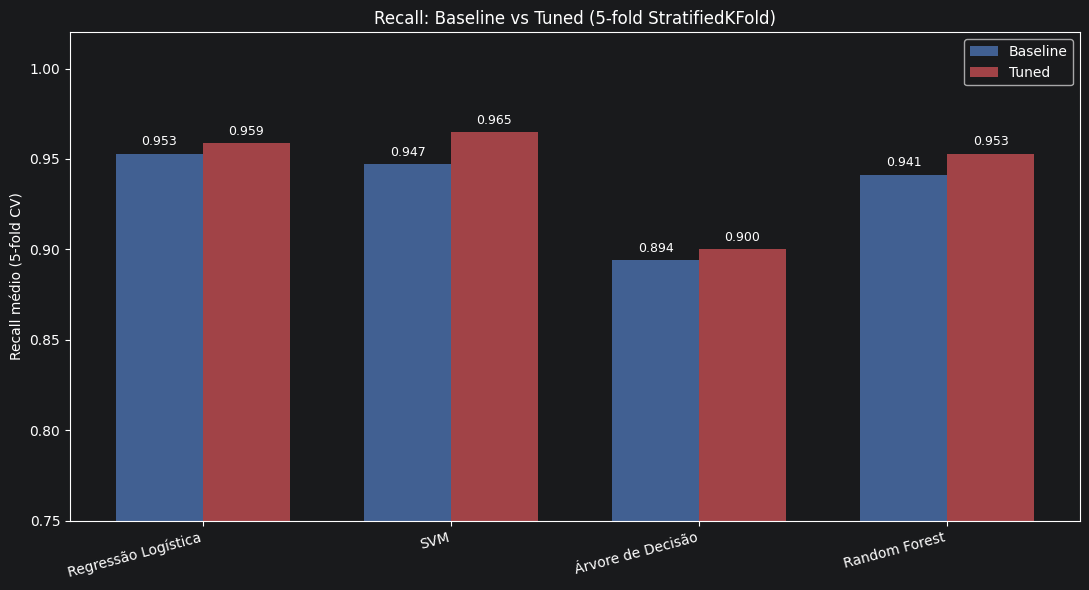

In [210]:
nomes = list(grids_tuned.keys())
recall_antes = [resultados_base[n]['Recall (média)'] for n in nomes]
recall_depois = [resultados_tuned[n]['Recall (média)'] for n in nomes]

x = range(len(nomes))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar([i - width/2 for i in x], recall_antes,  width, label='Baseline', color='#4C72B0', alpha=0.8)
bars2 = ax.bar([i + width/2 for i in x], recall_depois, width, label='Tuned',    color='#C44E52', alpha=0.8)

ax.set_xticks(list(x))
ax.set_xticklabels(nomes, rotation=15, ha='right')
ax.set_ylim(0.75, 1.02)
ax.set_ylabel('Recall médio (5-fold CV)')
ax.set_title('Recall: Baseline vs Tuned (5-fold StratifiedKFold)')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [211]:
# Selecionar o melhor modelo (maior recall médio pós-tuning)
# Empate: modelos dentro de 1 std do melhor recall são considerados empatados;
# entre empatados, vence o menor Recall (std) (mais estável nos folds).
melhor_recall = df_tuned['Recall (média)'].max()
melhor_std    = df_tuned.loc[df_tuned['Recall (média)'] == melhor_recall, 'Recall (std)'].min()

candidatos = df_tuned[
    df_tuned['Recall (média)'] >= melhor_recall - melhor_std
].copy()
melhor_nome = candidatos['Recall (std)'].idxmin()

melhor_grid   = grids_tuned[melhor_nome]
melhor_modelo = melhor_grid.best_estimator_

print(f'Melhor modelo selecionado (CV): {melhor_nome}')
print(f'  Recall CV:   {resultados_tuned[melhor_nome]["Recall (média)"]:.4f} '
      f'± {resultados_tuned[melhor_nome]["Recall (std)"]:.4f}')
print(f'  F1 CV:       {resultados_tuned[melhor_nome]["F1 (média)"]:.4f} '
      f'± {resultados_tuned[melhor_nome]["F1 (std)"]:.4f}')
print(f'  Accuracy CV: {resultados_tuned[melhor_nome]["Accuracy (média)"]:.4f} '
      f'± {resultados_tuned[melhor_nome]["Accuracy (std)"]:.4f}')
print('\nParâmetros do melhor modelo:')
print(f'  {melhor_grid.best_params_}')


Melhor modelo selecionado (CV): SVM
  Recall CV:   0.9647 ± 0.0288
  F1 CV:       0.9674 ± 0.0114
  Accuracy CV: 0.9758 ± 0.0082

Parâmetros do melhor modelo:
  {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}


---

## Etapa 5: Avaliação do Modelo

### 5.1 Diagnóstico de Overfitting / Underfitting

Comparamos o recall de treino (modelo ajustado sobre o treino completo) com o recall médio de CV (estimativa de generalização). Se treino >> CV, o modelo decorou os dados de treino (overfitting). Se ambos são baixos, o modelo é simples demais para capturar o padrão (underfitting). O resultado esperado é treino ≈ CV com valores altos, indicando boa generalização.


In [212]:
print('=== Diagnóstico Overfitting / Underfitting ===')
print(f'{"Modelo":<25} {"Treino":>8} {"CV (média)":>12} {"CV (std)":>10} {"Diferença":>11}')
print('-' * 70)

for nome, grid in grids_tuned.items():
    modelo = grid.best_estimator_
    treino_score = recall_score(y_train, modelo.predict(X_train))
    cv_scores    = cross_val_score(modelo, X_train, y_train, cv=cv, scoring=recall_scorer, n_jobs=-1)
    diferenca    = treino_score - cv_scores.mean()
    status = '⚠️  overfit' if diferenca > 0.05 else '✅ ok'
    print(f'{nome:<25} {treino_score:>8.4f} {cv_scores.mean():>12.4f} {cv_scores.std():>10.4f} {diferenca:>+11.4f}  {status}')

=== Diagnóstico Overfitting / Underfitting ===
Modelo                      Treino   CV (média)   CV (std)   Diferença
----------------------------------------------------------------------
Regressão Logística         0.9588       0.9588     0.0300     +0.0000  ✅ ok
SVM                         0.9706       0.9647     0.0288     +0.0059  ✅ ok
Árvore de Decisão           0.9765       0.9000     0.0576     +0.0765  ⚠️  overfit
Random Forest               0.9824       0.9529     0.0300     +0.0294  ✅ ok


### 5.2 Avaliação final no conjunto de teste

O conjunto de teste (`X_test`, `y_test`) é usado pela primeira e única vez aqui. Avaliamos todos os modelos tuned para comparação, e destacamos o melhor.

In [213]:
from sklearn.metrics import (accuracy_score, recall_score, f1_score,
                              precision_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

print('=== Avaliação no Conjunto de Teste ===')
print(f'{"Modelo":<25} {"Accuracy":>10} {"Recall":>8} {"F1":>8} {"Precision":>11}')
print('-' * 66)

resultados_teste = {}
for nome, grid in grids_tuned.items():
    y_pred = grid.best_estimator_.predict(X_test)
    resultados_teste[nome] = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1':        f1_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
    }
    r = resultados_teste[nome]
    print(f"{nome:<25} {r['Accuracy']:>10.4f} {r['Recall']:>8.4f} {r['F1']:>8.4f} {r['Precision']:>11.4f}")

=== Avaliação no Conjunto de Teste ===
Modelo                      Accuracy   Recall       F1   Precision
------------------------------------------------------------------
Regressão Logística           0.9737   1.0000   0.9655      0.9333
SVM                           0.9737   0.9286   0.9630      1.0000
Árvore de Decisão             0.9474   0.9048   0.9268      0.9500
Random Forest                 0.9737   0.9286   0.9630      1.0000


In [214]:
y_pred_melhor = melhor_modelo.predict(X_test)

print(f'=== Classification Report: {melhor_nome} ===')
print(classification_report(y_test, y_pred_melhor, target_names=CLASS_NAMES))

=== Classification Report: SVM ===
              precision    recall  f1-score   support

     Benigno       0.96      1.00      0.98        72
     Maligno       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



### 5.3 Matriz de Confusão

A matriz de confusão decompõe os erros do modelo em 4 quadrantes:

| | Predito Benigno | Predito Maligno |
|---|---|---|
| **Real Benigno** | **VN**: acerto (benigno corretamente identificado) | **FP**: alarme falso |
| **Real Maligno** | **FN**: erro crítico (maligno não detectado) | **VP**: acerto (maligno detectado) |

**FN (Falso Negativo)** é o erro mais grave em triagem oncológica: o paciente recebe alta sem tratamento. O objetivo de maximizar o recall é justamente minimizar a célula FN.

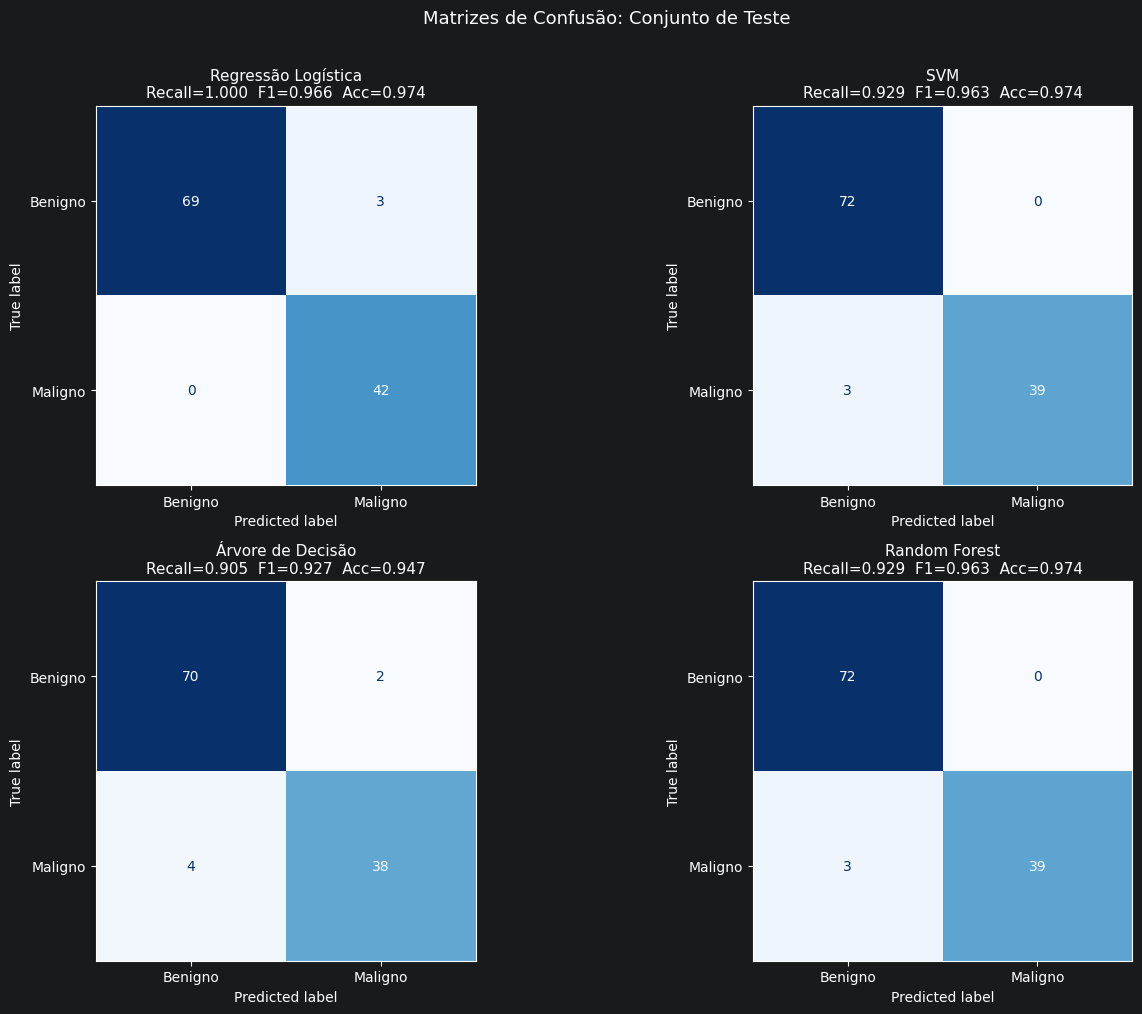

In [215]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (nome, grid) in enumerate(grids_tuned.items()):
    y_pred = grid.best_estimator_.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=axes[i], values_format='d', cmap='Blues', colorbar=False)
    r = resultados_teste[nome]
    axes[i].set_title(
        f'{nome}\nRecall={r["Recall"]:.3f}  F1={r["F1"]:.3f}  Acc={r["Accuracy"]:.3f}',
        fontsize=11
    )

plt.suptitle('Matrizes de Confusão: Conjunto de Teste', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 5.4 Curva ROC e AUC

A curva ROC plota **Recall (Sensibilidade)** no eixo Y contra **1 - Especificidade (Taxa de FP)** no eixo X, varrendo todos os thresholds de decisão (0→1). O **AUC** (Area Under Curve) resume a curva em um único número:

- **AUC = 1,0**: separação perfeita entre as classes.
- **AUC = 0,5**: equivalente a classificador aleatório (linha diagonal).


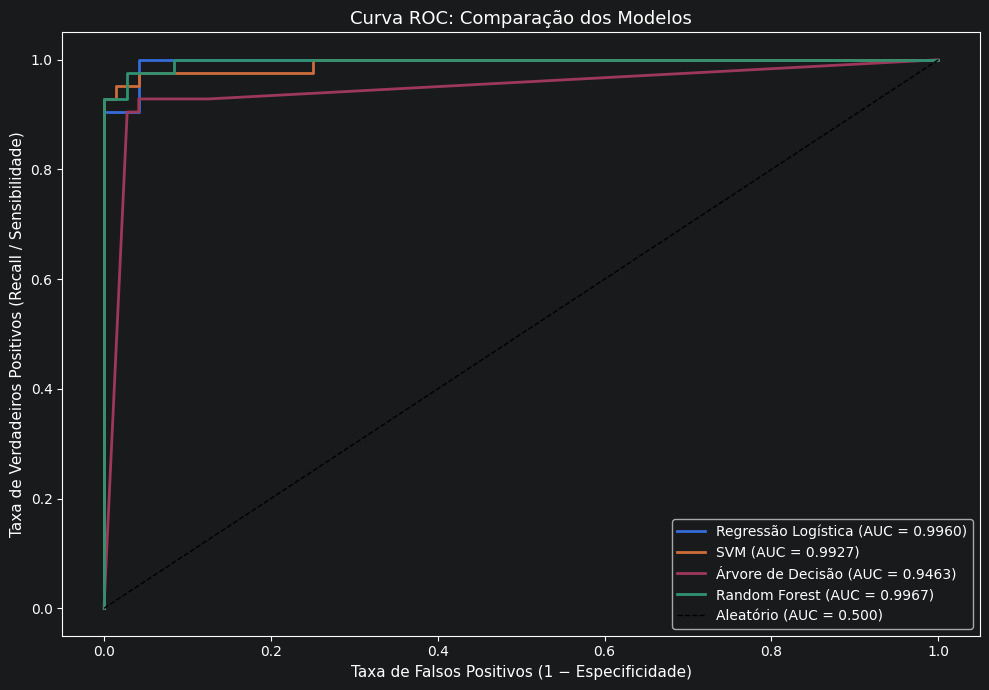

In [216]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 7))

for nome, grid in grids_tuned.items():
    modelo = grid.best_estimator_
    # predict_proba exige probability=True (SVC já configurado com probability=True)
    y_proba = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{nome} (AUC = {roc_auc:.4f})', linewidth=2)

# Linha de referência (classificador aleatório)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatório (AUC = 0.500)')

plt.xlabel('Taxa de Falsos Positivos (1 − Especificidade)', fontsize=11)
plt.ylabel('Taxa de Verdadeiros Positivos (Recall / Sensibilidade)', fontsize=11)
plt.title('Curva ROC: Comparação dos Modelos', fontsize=13)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [217]:
y_proba_melhor = melhor_modelo.predict_proba(X_test)[:, 1]
fpr_m, tpr_m, thresholds_m = roc_curve(y_test, y_proba_melhor)
auc_melhor = auc(fpr_m, tpr_m)

print(f'=== AUC: {melhor_nome} ===')
print(f'AUC no conjunto de teste: {auc_melhor:.4f}')
print()

# Ponto de operação atual (threshold=0.5)
y_pred_melhor = melhor_modelo.predict(X_test)
tp = ((y_pred_melhor == 1) & (y_test == 1)).sum()
fp = ((y_pred_melhor == 1) & (y_test == 0)).sum()
fn = ((y_pred_melhor == 0) & (y_test == 1)).sum()
tn = ((y_pred_melhor == 0) & (y_test == 0)).sum()

print(f'Conjunto de teste: {melhor_nome} (threshold padrão = 0.5):')
print(f'  Verdadeiros Positivos (VP): {tp} : malignos corretamente detectados')
print(f'  Verdadeiros Negativos (VN): {tn} : benignos corretamente identificados')
print(f'  Falsos Positivos     (FP): {fp}  : benignos classificados como malignos (alarme falso)')
print(f'  Falsos Negativos     (FN): {fn}  : malignos NÃO detectados (erro crítico)')
print()
print(f'Recall  = VP / (VP + FN) = {tp} / ({tp}+{fn}) = {tp/(tp+fn):.4f}')
print(f'Precision = VP / (VP + FP) = {tp} / ({tp}+{fp}) = {tp/(tp+fp):.4f}' if (tp+fp)>0 else '')

=== AUC: SVM ===
AUC no conjunto de teste: 0.9927

Conjunto de teste: SVM (threshold padrão = 0.5):
  Verdadeiros Positivos (VP): 39 : malignos corretamente detectados
  Verdadeiros Negativos (VN): 72 : benignos corretamente identificados
  Falsos Positivos     (FP): 0  : benignos classificados como malignos (alarme falso)
  Falsos Negativos     (FN): 3  : malignos NÃO detectados (erro crítico)

Recall  = VP / (VP + FN) = 39 / (39+3) = 0.9286
Precision = VP / (VP + FP) = 39 / (39+0) = 1.0000


### 5.5 Análise de Threshold

O threshold padrão de 0.5 classifica uma amostra como maligna quando a probabilidade estimada supera 50%. Em triagem oncológica, esse ponto de corte pode não ser o ideal: um falso negativo (maligno classificado como benigno) tem consequências clínicas muito mais graves do que um falso positivo (benigno classificado como maligno).

Reduzir o threshold aumenta o recall (o modelo passa a exigir menos certeza para emitir um alerta de malignidade), mas introduz mais falsos positivos. Esta seção quantifica esse trade-off com o modelo selecionado.

In [218]:
# Sweep discreto: métricas por threshold
# y_proba_melhor e thresholds_m já foram calculados na seção 5.4

thresholds_sweep = [0.2, 0.3, 0.4, 0.5]
rows = []

for t in thresholds_sweep:
    y_pred_t = (y_proba_melhor >= t).astype(int)
    tp = int(((y_pred_t == 1) & (y_test == 1)).sum())
    fp = int(((y_pred_t == 1) & (y_test == 0)).sum())
    fn = int(((y_pred_t == 0) & (y_test == 1)).sum())
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 1.0
    rows.append({'Threshold': t, 'Recall': round(recall, 4), 'Precision': round(precision, 4), 'FN': fn, 'FP': fp})

df_thresh = pd.DataFrame(rows)
print(df_thresh.to_string(index=False))

 Threshold  Recall  Precision  FN  FP
       0.2  0.9762     0.8913   1   5
       0.3  0.9524     0.9524   2   2
       0.4  0.9524     0.9756   2   1
       0.5  0.9286     1.0000   3   0


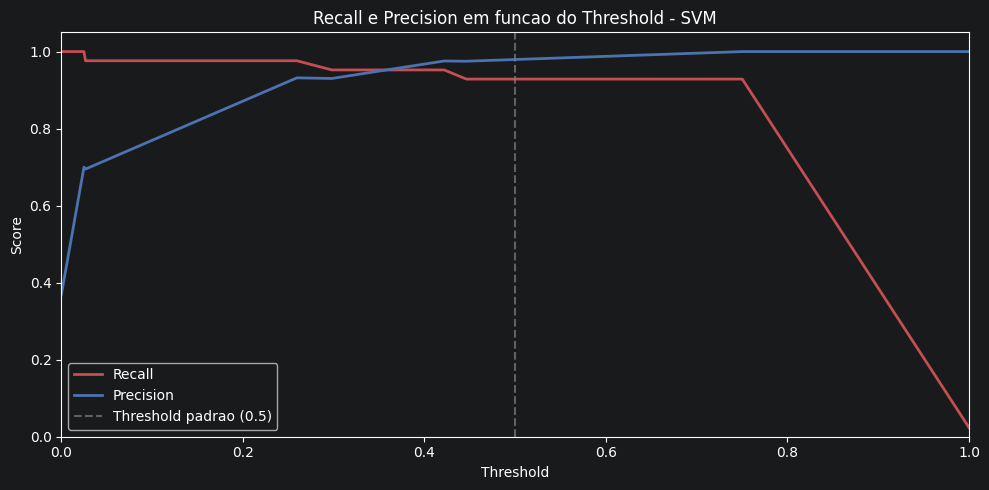

In [219]:
# Curva contínua de Recall e Precision sobre todos os thresholds da ROC
recalls_cont, precisions_cont = [], []

for t in thresholds_m:
    y_pred_t = (y_proba_melhor >= t).astype(int)
    tp = int(((y_pred_t == 1) & (y_test == 1)).sum())
    fp = int(((y_pred_t == 1) & (y_test == 0)).sum())
    fn = int(((y_pred_t == 0) & (y_test == 1)).sum())
    recalls_cont.append(tp / (tp + fn) if (tp + fn) > 0 else 0.0)
    precisions_cont.append(tp / (tp + fp) if (tp + fp) > 0 else 1.0)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds_m, recalls_cont,    label='Recall',    color='#C44E52', linewidth=2)
ax.plot(thresholds_m, precisions_cont, label='Precision', color='#4C72B0', linewidth=2)
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.7, label='Threshold padrao (0.5)')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title(f'Recall e Precision em funcao do Threshold - {melhor_nome}', fontsize=12)
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

Reduzir o threshold abaixo de 0.5 aumenta o recall (os 3 falsos negativos restantes podem ser recuperados), mas ao custo de introduzir falsos positivos: pacientes benignos que receberiam indicação desnecessária de procedimentos complementares.

Com threshold=0.5, o modelo já opera com FP=0 e Recall=0.9286. A curva acima mostra que ganhos de recall a partir desse ponto implicam queda de precision, sem zona de melhoria simultânea dos dois indicadores.

Com threshold=0.5, o modelo opera com FP=0 às custas de 3 FN. Threshold=0.2 elimina 2 desses FN, mas introduz 5 FP. Threshold=0.4 é o ponto de equilíbrio: reduz FN de 3 para 2 com apenas 1 FP adicional. A escolha depende do protocolo clínico adotado.

---

## Etapa 6: Interpretação com SHAP

**SHAP (SHapley Additive exPlanations)** quantifica a contribuição de cada feature para uma predição individual. Enquanto a análise de correlação (Etapa 2.6) e a seleção de features (Etapa 2.7.3) respondem *quais features são globalmente relevantes*, o SHAP responde: por que o modelo classificou este paciente específico assim?

Para cada predição, o SHAP decompõe a saída do modelo em contribuições aditivas por feature: valor positivo empurra para maligno, valor negativo para benigno. A soma dos valores SHAP mais o valor base (média do modelo) resulta na predição final.

Como o modelo final é um SVM com kernel `rbf` (caixa-preta), utilizamos o `KernelExplainer`: método model-agnóstico que estima os valores SHAP por amostragem de perturbações. É mais lento que o `TreeExplainer`, mas funciona com qualquer modelo. O background é um resumo do treino via `kmeans(X_train, 50)` e explicamos o conjunto de teste completo (`X_test`).


In [220]:
import shap

# Wrapper: converte numpy array para DataFrame antes de passar ao Pipeline
def predict_proba_fn(x):
    return melhor_modelo.predict_proba(pd.DataFrame(x, columns=X_test.columns))

background = shap.kmeans(X_train, 50)
explainer = shap.KernelExplainer(predict_proba_fn, background)
shap_values = explainer.shap_values(X_test, check_additivity=False)

# Extrair valores SHAP para a classe Maligno (classe 1)
# O formato varia por versao do SHAP: lista ou array 3D
if isinstance(shap_values, list):
    sv_maligno = shap_values[1]
elif shap_values.ndim == 3:
    sv_maligno = shap_values[:, :, 1]
else:
    sv_maligno = shap_values

print(f"Shape sv_maligno: {sv_maligno.shape}")
print(f"X_test shape:     {X_test.shape}")


  0%|          | 0/114 [00:00<?, ?it/s]

Shape sv_maligno: (114, 30)
X_test shape:     (114, 30)


### 6.1 Visão global: quais features mais influenciam o modelo?

O **beeswarm plot** mostra, para todas as amostras do teste, como cada feature impacta a predição de malignidade. Cada ponto é uma amostra; a cor indica o valor da feature (vermelho = alto, azul = baixo); a posição no eixo X indica a direção e magnitude da contribuição SHAP.


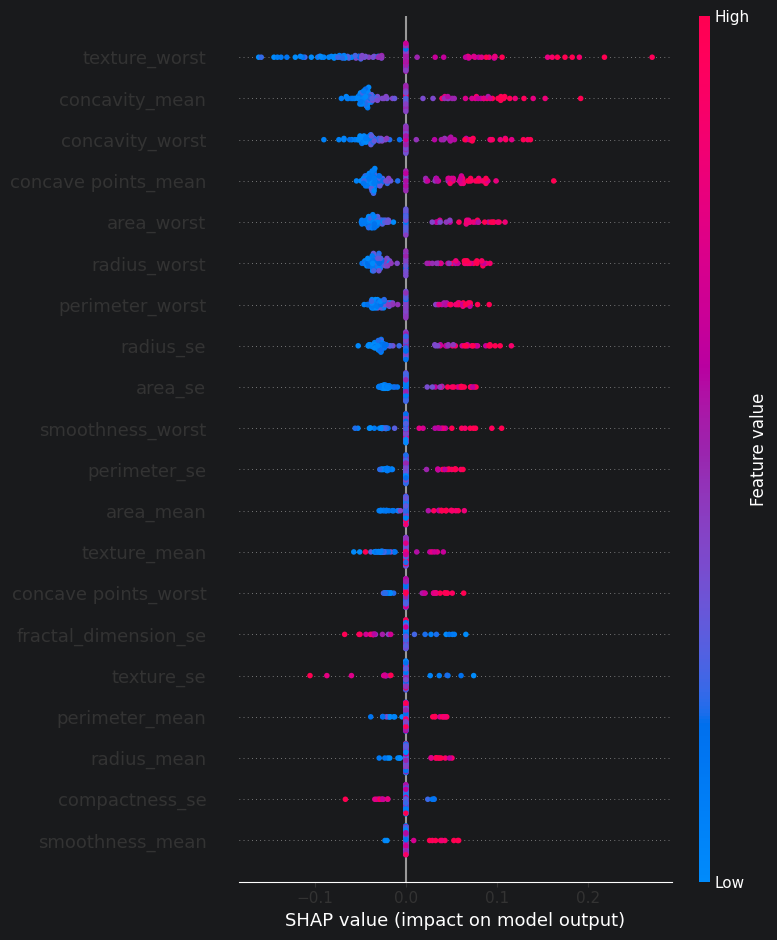

In [221]:
shap.summary_plot(
    sv_maligno,
    X_test,
    feature_names=X_test.columns.tolist(),
    plot_type='dot',
    show=True
)


### 6.2 Explicação individual: por que o modelo classificou este paciente assim?

O **waterfall plot** decompõe a predição de um paciente específico feature por feature. O valor base (`E[f(x)]`) é a predição média do modelo; cada barra mostra quanto uma feature aumentou (vermelho) ou diminuiu (azul) a probabilidade de malignidade em relação a essa base.

Analisamos dois casos: um benigno corretamente classificado e um maligno corretamente classificado.


=== Paciente classificado como Benigno ===


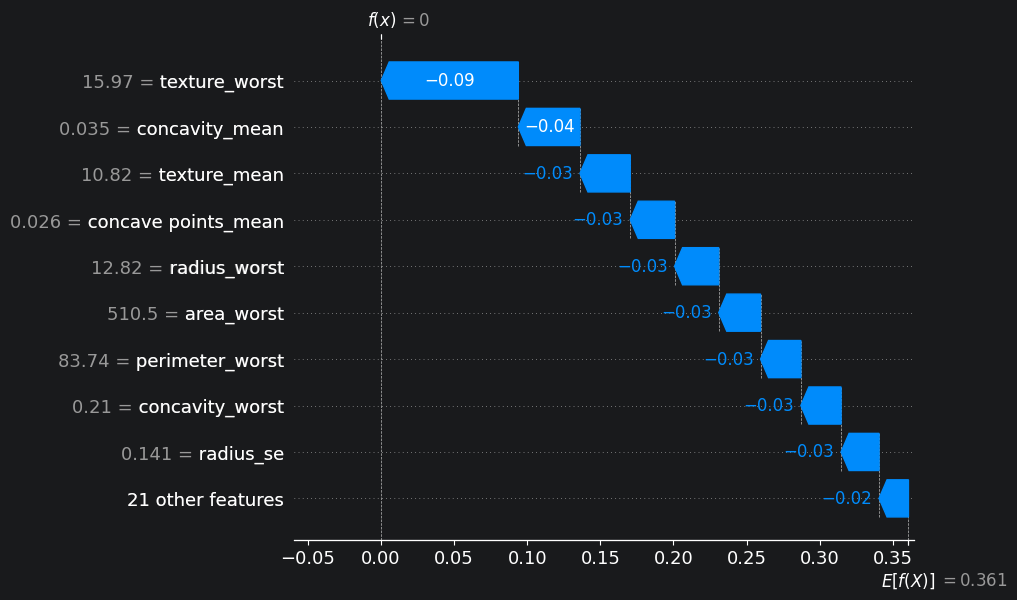

=== Paciente classificado como Maligno ===


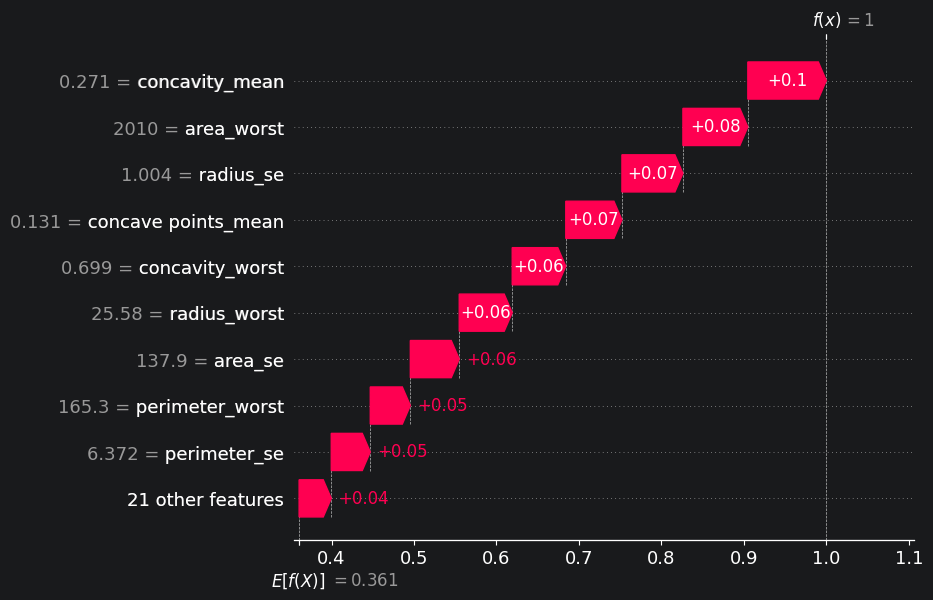

In [222]:
import numpy as np

y_pred_test = melhor_modelo.predict(X_test)
acertos_benigno = np.where((y_pred_test == 0) & (y_test.values == 0))[0]
acertos_maligno = np.where((y_pred_test == 1) & (y_test.values == 1))[0]

idx_b = acertos_benigno[0]
idx_m = acertos_maligno[0]

for idx, rotulo in [(idx_b, 'Benigno'), (idx_m, 'Maligno')]:
    print(f'=== Paciente classificado como {rotulo} ===')
    shap_exp = shap.Explanation(
        values=sv_maligno[idx],
        base_values=explainer.expected_value[1],
        data=X_test.iloc[idx].values,
        feature_names=X_test.columns.tolist()
    )
    shap.plots.waterfall(shap_exp, show=True)


---

## Etapa 7: Discussão Crítica


### 7.1 Análise comparativa: SVM × Regressão Logística

O modelo final é o **SVM**, selecionado pela validação cruzada (Etapa 4.4) com base no maior recall médio pós-tuning. A avaliação no conjunto de teste (Etapa 5.2) confirma desempenho expressivo.

A tabela abaixo compara o SVM com a Regressão Logística no conjunto de teste:


In [223]:
# Tabela comparativa gerada dinamicamente a partir das predicoes reais
modelos_comparar = ['SVM', 'Regressão Logística']

rows = []
for nome in modelos_comparar:
    y_pred = grids_tuned[nome].best_estimator_.predict(X_test)
    fn = int(((y_pred == 0) & (y_test == 1)).sum())
    fp = int(((y_pred == 1) & (y_test == 0)).sum())
    r  = resultados_teste[nome]
    cv = resultados_tuned[nome]
    label = f'{nome} (modelo final)' if nome == melhor_nome else nome
    rows.append({
        'Modelo':         label,
        'Recall CV':      f"{cv['Recall (média)']:.4f} ± {cv['Recall (std)']:.4f}",
        'Recall Teste':   round(r['Recall'],    4),
        'F1 Teste':       round(r['F1'],        4),
        'Precision':      round(r['Precision'], 4),
        'Accuracy':       round(r['Accuracy'],  4),
        'FN':             fn,
        'FP':             fp,
    })

df_comp = pd.DataFrame(rows).set_index('Modelo')
print(df_comp.to_string())
print(f'\nModelo final (CV): {melhor_nome}')
print(f'AUC no teste:      {auc_melhor:.4f}')
print(f'\nJustificativa da selecao: {melhor_nome} teve maior Recall CV '
      f'(ou igual com menor desvio padrao entre folds).')


                           Recall CV  Recall Teste  F1 Teste  Precision  Accuracy  FN  FP
Modelo                                                                                   
SVM (modelo final)   0.9647 ± 0.0288        0.9286    0.9630     1.0000    0.9737   3   0
Regressão Logística  0.9588 ± 0.0300        1.0000    0.9655     0.9333    0.9737   0   3

Modelo final (CV): SVM
AUC no teste:      0.9927

Justificativa da selecao: SVM teve maior Recall CV (ou igual com menor desvio padrao entre folds).


Trade-off clínico observado no teste:

- O SVM zerou os Falsos Positivos (nenhum benigno classificado erroneamente) mas gerou Falsos Negativos: pacientes malignos não detectados.
- A Regressão Logística zerou os Falsos Negativos ao custo de Falsos Positivos: alarmes que levam a biópsia confirmatória.

Em triagem oncológica, FN é o erro mais grave (atraso no tratamento, potencialmente fatal), enquanto FP é reversível (biópsia confirmatória). Esse trade-off sugere que, para este problema clínico específico, a Regressão Logística apresentaria comportamento mais seguro no teste.

Limitação metodológica: a discrepância entre o modelo selecionado por CV e o modelo com menor FN no teste indica que o recall médio de CV não capturou completamente o comportamento clínico real. Possíveis causas: variância entre folds ou diferenças de calibração de probabilidade entre os modelos. Como melhoria futura, duas abordagens complementares: `class_weight` no estimador (penaliza erros na classe maligna durante o treino) e `make_scorer` com custo assimétrico no GridSearchCV (otimiza diretamente a métrica clínica na busca de hiperparâmetros).

Interpretabilidade: o SVM com kernel `rbf` não expõe coeficientes por feature. Para compensar, a Etapa 6 aplica **SHAP** com `KernelExplainer`, quantificando a contribuição de cada feature para cada predição individual e permitindo auditoria clínica mesmo em modelos caixa-preta.


### 7.2 Conclusão

O **SVM com kernel `rbf`** foi eleito modelo final pelo maior recall médio de CV pós-tuning (Etapa 4.4), sem exposição ao conjunto de teste. No teste (avaliação única, Etapa 5.2): AUC = 0,9927 | Recall = 0,9286 | Precision = 1,0000, com 3 FN e 0 FP. A análise crítica do trade-off clínico FN × FP, a discrepância entre CV e teste, e a discussão de interpretabilidade estão detalhadas na Etapa 7.1.

Limitações do estudo:

- Dataset de tamanho moderado (569 amostras), sem validação em coorte externa.
- Features derivadas de imagens de Fine Needle Aspirate, com variabilidade dependente da qualidade da amostra.
- Ausência de custo assimétrico explícito (FN >> FP) no scorer de tuning.



---

## Etapa 8: Serialização dos modelos

Os dois melhores pipelines (StandardScaler + SVM e StandardScaler + Regressão Logística) são salvos em `models/`. Salvar o pipeline completo garante que o scaler ajustado no treino seja aplicado automaticamente em qualquer nova predição.


In [224]:
import joblib
from pathlib import Path

models_dir = Path('../models')
models_dir.mkdir(exist_ok=True)

modelos_salvar = {
    'svm':                 grids_tuned['SVM'].best_estimator_,
    'regressao_logistica': grids_tuned['Regressão Logística'].best_estimator_,
}

for nome, pipeline in modelos_salvar.items():
    path = models_dir / f'breast_cancer_{nome}.joblib'
    joblib.dump(pipeline, path)
    print(f'Salvo: {path.resolve()}')


Salvo: /home/milagre/ambiente/fiap/ia-for-devs-phase1-tech-challenge/models/breast_cancer_svm.joblib
Salvo: /home/milagre/ambiente/fiap/ia-for-devs-phase1-tech-challenge/models/breast_cancer_regressao_logistica.joblib


In [225]:
# Exemplo de uso: carregar e predizer
svm_carregado = joblib.load('../models/breast_cancer_svm.joblib')
lr_carregado  = joblib.load('../models/breast_cancer_regressao_logistica.joblib')

for nome, modelo in [('SVM', svm_carregado), ('Regressao Logistica', lr_carregado)]:
    y_pred  = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]
    fn = int(((y_pred == 0) & (y_test == 1)).sum())
    fp = int(((y_pred == 1) & (y_test == 0)).sum())
    print(f'{nome}: FN={fn}  FP={fp}  primeiras probabilidades={y_proba[:3].round(3).tolist()}')


SVM: FN=3  FP=0  primeiras probabilidades=[0.0, 1.0, 0.014]
Regressao Logistica: FN=0  FP=3  primeiras probabilidades=[0.392, 0.779, 0.529]
